In [1]:
!pip install -r ../requirements.txt

## Data Processing

In [2]:
# REPLACEMENT Cell 1: Robust processing & preprocessing (no leakage, no NaNs)
# - Resamples each subject to a strict 5-minute grid
# - Uses the PyKalman smoothing helper when available
# - Reindexes smoother output to 5-min grid and fills remaining gaps
# - Splits by subject into train/test BEFORE fitting scalers (80/20)
# - Produces per_subject_train, per_subject_test, X_tr_all, y_tr_all, cg_scaler, feat_scaler
# Run this cell in place of the earlier preprocessing cell.

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from datetime import timedelta
import sys, subprocess

# ensure smoothing helper installed (same as before)
subprocess.check_call([sys.executable, "-m", "pip", "install", "git+https://github.com/miriamkw/PyKalmanSmoothingGlucose.git"], stdout=subprocess.DEVNULL)
from smoother.smooth_SMBG_data import smooth_smbg_data

# Parameters (easy to change)
DATA_PATH = "../data/OhioT1DM.csv"
N_IN = 12   # history (12*5 = 60 min)
N_OUT = 6   # horizon (6*5 = 30 min)
RANDOM_STATE = 42
RESAMPLE_RULE = '5T'  # 5 minutes

# Read and sort
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['id','date']).reset_index(drop=True)

# Features to keep (same as before)
feat_cols = ['carbs','bolus','basal','galvanic_skin_response','skin_temp',
             'acceleration','workout_intensity','workout_duration','heartrate','air_temp','steps']
all_features = ['CGM'] + feat_cols

# Helper: robust smoothing + reindexing to regular 5-min grid
def smooth_and_resample_subject(df_sub):
    """
    Input: df_sub sorted by date for a single subject
    Output: df_reg indexed by a strict 5-min grid from min->max with no NaNs in CGM_smoothed or feature columns
    """
    # create full regular index (5-min) spanning subject's time range
    tmin = df_sub['date'].min()
    tmax = df_sub['date'].max()
    # ensure we extend to include endpoints cleanly
    full_idx = pd.date_range(start=tmin.floor('5T'), end=tmax.ceil('5T'), freq=RESAMPLE_RULE)
    # original times and values
    t_orig = df_sub['date'].values
    y_orig = df_sub['CGM'].values.astype(float)

    # Try Kalman smoother on original points (works on irregular timestamps)
    y_smooth_at_out = None
    try:
        res = smooth_smbg_data(t_orig, y_orig, outlier_removal=1, dynamic_model=2)
        # prefer 'y_smoothed_at_tout' if present (smoother evaluated at requested grid)
        y_s = res.get('y_smoothed_at_tout', res.get('y_smoothed', None))
        if y_s is not None:
            # 'y_s' is aligned with the input timestamps by default; we'll map it to timestamps
            # If there's an explicit 'tout' use that; otherwise map to original times
            tout = res.get('tout', None)
            if tout is not None:
                # create series at the smoother's output times -> reindex to 5-min grid
                smooth_series = pd.Series(y_s, index=pd.to_datetime(tout))
            else:
                smooth_series = pd.Series(y_s, index=df_sub['date'].values)
            # reindex to regular grid by interpolation
            smooth_reg = smooth_series.reindex(smooth_series.index.union(full_idx)).sort_index().interpolate(method='time').reindex(full_idx)
            y_smooth_at_out = smooth_reg.values
    except Exception:
        y_smooth_at_out = None

    # Fallback: if Kalman smoothing failed or produced NaNs, do robust pandas interpolation + median filter
    if y_smooth_at_out is None or np.isnan(y_smooth_at_out).all():
        # Build a series of original CGM at original times then reindex and interpolate
        s_orig = pd.Series(y_orig, index=df_sub['date'].values)
        s_reg = s_orig.reindex(s_orig.index.union(full_idx)).sort_index().interpolate(method='time').reindex(full_idx)
        # small rolling median to reduce spikes (window 3)
        s_med = s_reg.rolling(window=3, min_periods=1, center=True).median()
        y_smooth_at_out = s_med.values

    # Now ensure no NaNs remain: interpolation -> forward/back fill -> replace remaining with global median of subject raw CGM
    y_series = pd.Series(y_smooth_at_out, index=full_idx)
    if y_series.isna().any():
        y_series = y_series.interpolate(limit_direction='both')
    if y_series.isna().any():
        y_series = y_series.fillna(method='ffill').fillna(method='bfill')
    if y_series.isna().any():
        # last resort: fill with subject median (should rarely happen)
        subj_med = np.nanmedian(y_orig) if np.isfinite(y_orig).any() else 100.0
        y_series = y_series.fillna(subj_med)

    # For other features: we resample to full grid and forward-fill/backfill
    df_sub_idx = df_sub.set_index('date')
    # keep only the feature columns we care about
    other = df_sub_idx.reindex(df_sub_idx.index.union(full_idx))[feat_cols].sort_index()
    other = other.interpolate(method='time').reindex(full_idx)
    # forward/backfill any remaining NaNs and replace all-NaN columns with zeros if necessary
    other = other.fillna(method='ffill').fillna(method='bfill').fillna(0.0)

    # assemble output dataframe
    out = other.copy()
    out = out.assign(CGM_smoothed = y_series.values)
    out = out.reset_index().rename(columns={'index':'date'})
    # ensure column order
    cols = ['date','CGM_smoothed'] + feat_cols
    out = out[cols]
    return out

# Process all subjects
per_subject = {}
for sid, g in df.groupby('id'):
    g_sorted = g.sort_values('date').reset_index(drop=True)
    per_subject[sid] = smooth_and_resample_subject(g_sorted)

# Ensure no NaNs anywhere in CGM_smoothed across subjects (sanity check)
for sid, df_s in per_subject.items():
    if df_s['CGM_smoothed'].isna().any():
        raise RuntimeError(f"NaNs remain in CGM_smoothed for subject {sid} after smoothing/filling.")

# Split subjects into train/test (80/20) BEFORE fitting scalers to avoid leakage
subject_ids = sorted(list(per_subject.keys()))
train_ids, test_ids = train_test_split(subject_ids, test_size=0.2, random_state=RANDOM_STATE)
print(f"Subjects total: {len(subject_ids)}  train: {len(train_ids)}  test: {len(test_ids)}")

# Fit scalers only on training subjects (no leakage)
all_cgm_train = np.concatenate([per_subject[s]['CGM_smoothed'].values for s in train_ids])
cg_scaler = MinMaxScaler(feature_range=(0,1))
cg_scaler.fit(all_cgm_train.reshape(-1,1))

# Fit feature scaler on training subject rows stacked
all_feats = []
for s in train_ids:
    all_feats.append(per_subject[s][feat_cols].values)
all_feats = np.vstack(all_feats)
feat_scaler = StandardScaler()
feat_scaler.fit(all_feats)

# Sequence creation (same as earlier but robust about empty outputs)
def create_sequences(df_s, n_in=N_IN, n_out=N_OUT):
    """
    produce X (n_samples, n_in, n_features) and y (n_samples, n_out, 1)
    where first channel is scaled CGM and remaining channels are scaled features
    """
    X_list = []
    y_list = []
    cgm = df_s['CGM_smoothed'].values.astype(float)
    other = df_s[feat_cols].values.astype(float)
    # scale
    cgm_s = cg_scaler.transform(cgm.reshape(-1,1)).reshape(-1)
    other_s = feat_scaler.transform(other)
    L = len(df_s)
    for i in range(n_in, L - n_out + 1):
        xin = np.column_stack([cgm_s[i-n_in:i], other_s[i-n_in:i]])  # shape (n_in, 1+len(feat_cols))
        yout = cgm_s[i:i+n_out].reshape(n_out,1)
        X_list.append(xin)
        y_list.append(yout)
    if len(X_list) == 0:
        return np.zeros((0,n_in,1+len(feat_cols))), np.zeros((0,n_out,1))
    X = np.stack(X_list)
    y = np.stack(y_list)
    return X, y

# Build per_subject_train and per_subject_test
per_subject_train = {}
per_subject_test = {}
for sid in train_ids:
    X,y = create_sequences(per_subject[sid])
    per_subject_train[sid] = {'X':X,'y':y}
for sid in test_ids:
    X,y = create_sequences(per_subject[sid])
    per_subject_test[sid] = {'X':X,'y':y}

# Aggregate X_tr_all, y_tr_all (concatenate across train subjects) safely
X_tr_list = [per_subject_train[s]['X'] for s in per_subject_train if per_subject_train[s]['X'].shape[0] > 0]
y_tr_list = [per_subject_train[s]['y'] for s in per_subject_train if per_subject_train[s]['y'].shape[0] > 0]
if len(X_tr_list) > 0:
    X_tr_all = np.concatenate(X_tr_list, axis=0)
    y_tr_all = np.concatenate(y_tr_list, axis=0)
else:
    X_tr_all = np.zeros((0,N_IN,1+len(feat_cols)))
    y_tr_all = np.zeros((0,N_OUT,1))

print("Finished preprocessing.")
print("X_tr_all shape:", X_tr_all.shape, "y_tr_all shape:", y_tr_all.shape)
# These variables are now safe (no NaNs) and ready for training the models.


C:\Users\msbdj\AppData\Local\Temp\ipykernel_12692\1076002460.py:47: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(start=tmin.floor('5T'), end=tmax.ceil('5T'), freq=RESAMPLE_RULE)


Autodetected mg/dL as unit
Smoother flagged measurement 1743 as outlier: t = 10045.0, y = 8.769008769008769 [mmol/L].
Smoother flagged measurement 8689 as outlier: t = 47370.0, y = 6.382506382506382 [mmol/L].
Smoother flagged measurement 14727 as outlier: t = 80995.0, y = 16.87201687201687 [mmol/L].
Smoother flagged measurement 14728 as outlier: t = 81000.0, y = 12.654012654012654 [mmol/L].
Smoother needs a second pass due to outliers detected. Total # outliers in input data: 4


C:\Users\msbdj\AppData\Local\Temp\ipykernel_12692\1076002460.py:99: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  other = other.fillna(method='ffill').fillna(method='bfill').fillna(0.0)
C:\Users\msbdj\AppData\Local\Temp\ipykernel_12692\1076002460.py:47: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(start=tmin.floor('5T'), end=tmax.ceil('5T'), freq=RESAMPLE_RULE)


Autodetected mg/dL as unit
Smoother flagged measurement 975 as outlier: t = 5055.0, y = 4.828504828504828 [mmol/L].
Smoother flagged measurement 1563 as outlier: t = 7995.0, y = 15.54001554001554 [mmol/L].
Smoother flagged measurement 1564 as outlier: t = 8000.0, y = 14.263514263514264 [mmol/L].
Smoother flagged measurement 1566 as outlier: t = 8010.0, y = 9.268509268509268 [mmol/L].
Smoother flagged measurement 1574 as outlier: t = 8050.0, y = 13.32001332001332 [mmol/L].
Smoother flagged measurement 1575 as outlier: t = 8055.0, y = 12.543012543012543 [mmol/L].
Smoother flagged measurement 1577 as outlier: t = 8065.0, y = 8.935508935508935 [mmol/L].
Smoother flagged measurement 1608 as outlier: t = 8220.0, y = 9.213009213009213 [mmol/L].
Smoother flagged measurement 1610 as outlier: t = 8230.0, y = 6.715506715506716 [mmol/L].
Smoother flagged measurement 1615 as outlier: t = 8255.0, y = 9.046509046509046 [mmol/L].
Smoother flagged measurement 1617 as outlier: t = 8265.0, y = 5.99400599

C:\Users\msbdj\AppData\Local\Temp\ipykernel_12692\1076002460.py:99: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  other = other.fillna(method='ffill').fillna(method='bfill').fillna(0.0)
C:\Users\msbdj\AppData\Local\Temp\ipykernel_12692\1076002460.py:47: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(start=tmin.floor('5T'), end=tmax.ceil('5T'), freq=RESAMPLE_RULE)


...

Autodetected mg/dL as unit
Smoother flagged measurement 267 as outlier: t = 2360.0, y = 16.206016206016205 [mmol/L].
Smoother flagged measurement 4922 as outlier: t = 26710.0, y = 9.879009879009878 [mmol/L].
Smoother flagged measurement 7918 as outlier: t = 46800.0, y = 5.328005328005328 [mmol/L].
Smoother flagged measurement 7997 as outlier: t = 47445.0, y = 5.55000555000555 [mmol/L].
Smoother flagged measurement 8020 as outlier: t = 47565.0, y = 9.324009324009324 [mmol/L].
Smoother flagged measurement 8183 as outlier: t = 48895.0, y = 7.548007548007548 [mmol/L].
Smoother flagged measurement 8878 as outlier: t = 54555.0, y = 11.71051171051171 [mmol/L].
Smoother flagged measurement 9048 as outlier: t = 55425.0, y = 8.935508935508935 [mmol/L].
Smoother flagged measurement 9052 as outlier: t = 55445.0, y = 6.271506271506271 [mmol/L].
Smoother flagged measurement 9054 as outlier: t = 55455.0, y = 8.824508824508824 [mmol/L].
Smoother flagged measurement 9055 as outlier: t = 55460.0, y = 8.

C:\Users\msbdj\AppData\Local\Temp\ipykernel_12692\1076002460.py:99: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  other = other.fillna(method='ffill').fillna(method='bfill').fillna(0.0)
C:\Users\msbdj\AppData\Local\Temp\ipykernel_12692\1076002460.py:47: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(start=tmin.floor('5T'), end=tmax.ceil('5T'), freq=RESAMPLE_RULE)


Autodetected mg/dL as unit
Smoother flagged measurement 624 as outlier: t = 8070.0, y = 3.4410034410034407 [mmol/L].
Smoother flagged measurement 625 as outlier: t = 8075.0, y = 6.271506271506271 [mmol/L].
Smoother flagged measurement 779 as outlier: t = 9595.0, y = 7.104007104007104 [mmol/L].
Smoother flagged measurement 1734 as outlier: t = 14395.0, y = 13.264513264513264 [mmol/L].
Smoother flagged measurement 2199 as outlier: t = 19905.0, y = 6.438006438006438 [mmol/L].
Smoother flagged measurement 2200 as outlier: t = 19910.0, y = 9.37950937950938 [mmol/L].
Smoother flagged measurement 2367 as outlier: t = 20930.0, y = 10.71151071151071 [mmol/L].
Smoother flagged measurement 2508 as outlier: t = 21635.0, y = 10.989010989010989 [mmol/L].
Smoother flagged measurement 2730 as outlier: t = 22750.0, y = 5.772005772005771 [mmol/L].
Smoother flagged measurement 3916 as outlier: t = 29285.0, y = 5.772005772005771 [mmol/L].
Smoother flagged measurement 5538 as outlier: t = 38705.0, y = 7.10

C:\Users\msbdj\AppData\Local\Temp\ipykernel_12692\1076002460.py:99: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  other = other.fillna(method='ffill').fillna(method='bfill').fillna(0.0)


Subjects total: 12  train: 9  test: 3
Finished preprocessing.
X_tr_all shape: (142531, 12, 12) y_tr_all shape: (142531, 6, 1)


Bergman fit windows: 142531
bergman epoch 1/10, loss=231.5888
Fitted bergman params: (0.009226962924003601, -0.14393314719200134, -0.030178789049386978, 2.3867976665496826, 157.89186096191406)
Epoch 1/30
1114/1114 - 15s - 14ms/step - loss: 0.0051
Epoch 2/30
1114/1114 - 11s - 10ms/step - loss: 0.0015
Epoch 3/30
1114/1114 - 11s - 10ms/step - loss: 0.0011
Epoch 4/30
1114/1114 - 11s - 10ms/step - loss: 9.3400e-04
Epoch 5/30
1114/1114 - 11s - 10ms/step - loss: 8.3856e-04
Epoch 6/30
1114/1114 - 11s - 10ms/step - loss: 7.6490e-04
Epoch 7/30
1114/1114 - 11s - 10ms/step - loss: 7.0992e-04
Epoch 8/30
1114/1114 - 11s - 10ms/step - loss: 6.6764e-04
Epoch 9/30
1114/1114 - 11s - 10ms/step - loss: 6.3884e-04
Epoch 10/30
1114/1114 - 11s - 10ms/step - loss: 6.1343e-04
Epoch 11/30
1114/1114 - 11s - 10ms/step - loss: 5.9354e-04
Epoch 12/30
1114/1114 - 11s - 10ms/step - loss: 5.7203e-04
Epoch 13/30
1114/1114 - 11s - 10ms/step - loss: 5.5663e-04
Epoch 14/30
1114/1114 - 11s - 10ms/step - loss: 5.4007e-04
Ep

  0%|          | 0/30 [00:00<?, ?it/s]

SHAP final-step feature importance (sum abs over time):
{'CGM_hist': 10.664430656252794, 'carbs': 0.6012086897674005, 'bolus': 2.6278363117203187, 'basal': 1.8629761814662085, 'galvanic_skin_response': 1.3316226681234702, 'skin_temp': 1.1696625399260028, 'acceleration': 0.7415937202352036, 'workout_intensity': 3.197828243683567, 'workout_duration': 1.388388302964719, 'heartrate': 0.9011547676016701, 'air_temp': 1.656606352292119, 'steps': 0.7295549229288119}


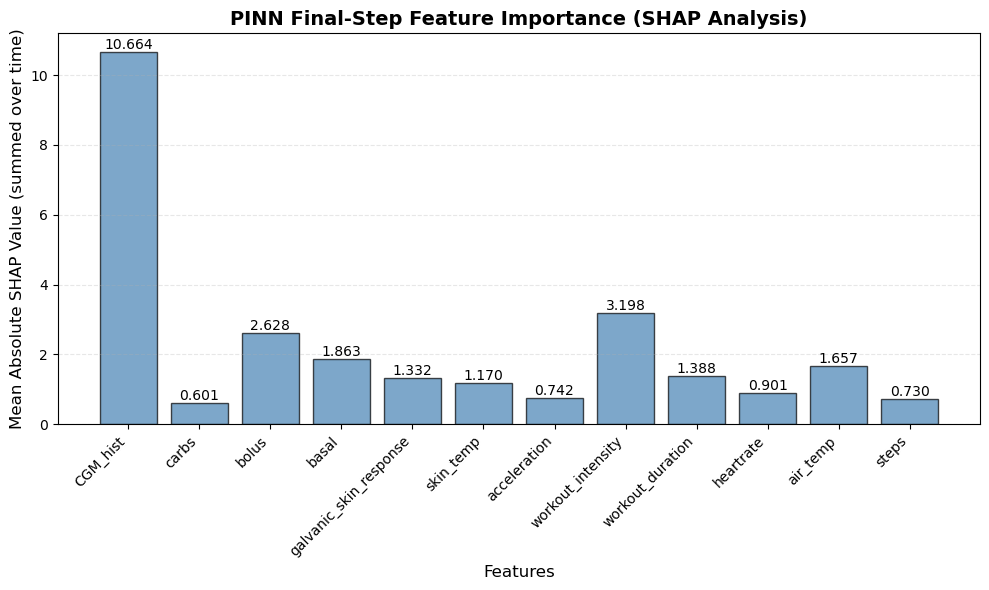

Model cell finished: persistence, bergman, PINN(LSTM) and ml_corrector ready.


In [8]:
# Model cell: feature engineering, model implementations, training and SHAP test.
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, losses, optimizers
import math
import random
import subprocess, sys
# install shap for feature importance test
subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"], stdout=subprocess.DEVNULL)
import shap
import matplotlib.pyplot as plt

# ---------------------------
# Quick config (change here)
# ---------------------------
EPOCHS_BERGMAN = 10
EPOCHS_LSTM = 30
EPOCHS_PINN = 30
BATCH = 16
LR = 1e-3
LAMBDA_PHYS = 1.0   # weight for the physics loss in PINN
LEARN_BERGMAN_DURING_PINN = True  # continue to adapt bergman params within PINN
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED); tf.random.set_seed(RANDOM_SEED); random.seed(RANDOM_SEED)

# some convenience
n_feats = 1 + len(feat_cols)
dt_minutes = 5.0
dt_scale = dt_minutes / dt_minutes  # =1 for our discrete scheme

# ---------------------------
# Helper: invert cg scaler quickly (vectorized)
# ---------------------------
cg_min = float(cg_scaler.data_min_[0])
cg_max = float(cg_scaler.data_max_[0])
cg_range = cg_max - cg_min if cg_max > cg_min else 1.0

def inv_cgm_scaled_tf(x_scaled):
    # x_scaled is Tensor in [0,1] shape (...); returns mg/dL same shape
    return x_scaled * cg_range + cg_min

def scale_cgm_np(x_mg):
    # numpy helper to scale mg->scaled
    flat = np.asarray(x_mg).reshape(-1,1)
    return cg_scaler.transform(flat).reshape(flat.shape[0],).reshape(x_mg.shape)

# ---------------------------
# Persistence baseline
# ---------------------------
def persistence_predict_for_subject(sid):
    info = per_subject_test.get(sid, None)
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT, 1))
    # each window: use last observed CGM (the last step of the history) and repeat
    Xs = info['X']  # scaled
    last = Xs[:, -1, 0]  # last cgm scaled
    preds = np.tile(last.reshape(-1,1), (1, N_OUT))
    return preds.reshape(preds.shape[0], N_OUT, 1)

persistence_model = {'predict': persistence_predict_for_subject}

# ---------------------------
# Bergman minimal model fit (trainable parameters)
# We'll fit p1,p2,p3,k_i,Gb by minimizing MSE between Bergman simulated G and truth (mg/dL).
# ---------------------------
# Build training arrays (windows) from per_subject_train
G_inits = []   # initial G at t0 (mg/dL)
carb_fut = []  # (n_windows, N_OUT)
bolus_fut = []
y_true_mg_windows = []  # (n_windows, N_OUT)
for sid, info in per_subject_train.items():
    subj = per_subject[sid]
    Xs = info['X']; ys = info['y']
    n_windows = Xs.shape[0]
    if n_windows == 0: continue
    # unscaled y to mg/dL
    y_scaled = ys.reshape(n_windows, N_OUT)
    y_mg = cg_scaler.inverse_transform(y_scaled.reshape(-1,1)).reshape(-1, N_OUT)
    # G_inits: subject['CGM_smoothed'][N_IN-1 : N_IN-1 + n_windows]
    G_init = subj['CGM_smoothed'].values[N_IN-1 : N_IN-1 + n_windows]
    # future bolus and carbs starting at index N_IN .. N_IN + n_windows + N_OUT-1 (we slice window wise)
    bolus_mat = np.zeros((n_windows, N_OUT))
    carb_mat = np.zeros((n_windows, N_OUT))
    for w in range(n_windows):
        start = N_IN + w
        bolus_mat[w,:] = subj['bolus'].values[start:start+N_OUT]
        carb_mat[w,:]  = subj['carbs'].values[start:start+N_OUT]
    G_inits.append(G_init)
    carb_fut.append(carb_mat)
    bolus_fut.append(bolus_mat)
    y_true_mg_windows.append(y_mg)

if len(G_inits) > 0:
    G_inits = np.concatenate(G_inits, axis=0)
    carb_fut = np.vstack(carb_fut)
    bolus_fut = np.vstack(bolus_fut)
    y_true_mg_windows = np.vstack(y_true_mg_windows)
else:
    G_inits = np.zeros((0,))
    carb_fut = np.zeros((0,N_OUT))
    bolus_fut = np.zeros((0,N_OUT))
    y_true_mg_windows = np.zeros((0,N_OUT))

print("Bergman fit windows:", G_inits.shape[0])

# initialize trainable bergman variables (start from simple plausible values)
p1 = tf.Variable(0.01, dtype=tf.float32, name='p1')   # glucose decay
p2 = tf.Variable(0.01, dtype=tf.float32, name='p2')   # insulin effect
p3 = tf.Variable(0.01, dtype=tf.float32, name='p3')   # meal effect
k_i = tf.Variable(0.1, dtype=tf.float32, name='k_i') # insulin clearance (discrete)
Gb = tf.Variable(np.median(G_inits) if G_inits.size>0 else 100.0, dtype=tf.float32, name='Gb')

opt_b = tf.keras.optimizers.Adam(learning_rate=1e-2)

# vectorized bergman simulator (tf)
@tf.function
def bergman_simulate_tf(G0, bolus_mat_tf, carb_mat_tf, p1v, p2v, p3v, k_iv, Gbv):
    """
    G0: shape (batch,)
    bolus_mat_tf, carb_mat_tf: shape (batch, N_OUT)
    returns: simulated G shape (batch, N_OUT)
    uses discrete Euler: G_{t+1} = G_t + dt*( -p1*(G_t-Gb) - p2*I_t + p3*carbs_t ), I_{t+1} = I_t*exp(-k_i) + bolus_t
    """
    batch = tf.shape(G0)[0]
    G = tf.cast(G0, tf.float32)
    I = tf.zeros_like(G, dtype=tf.float32)
    out = tf.TensorArray(tf.float32, size=N_OUT)
    exp_k = tf.exp(-k_iv)
    for t in tf.range(N_OUT):
        bol = tf.cast(bolus_mat_tf[:,t], tf.float32)
        carb = tf.cast(carb_mat_tf[:,t], tf.float32)
        I = I * exp_k + bol
        dG = -p1v * (G - Gbv) - p2v * I + p3v * carb
        G = G + dG * dt_scale
        out = out.write(t, G)
    Gs = tf.transpose(out.stack(), perm=[1,0])  # (batch, N_OUT)
    return Gs

# training loop to fit bergman params
if G_inits.shape[0] > 0:
    dataset = tf.data.Dataset.from_tensor_slices((G_inits.astype(np.float32),
                                                  bolus_fut.astype(np.float32),
                                                  carb_fut.astype(np.float32),
                                                  y_true_mg_windows.astype(np.float32)))
    dataset = dataset.shuffle(10000, seed=RANDOM_SEED).batch(BATCH).prefetch(1)

    for epoch in range(EPOCHS_BERGMAN):
        epoch_loss = 0.0; n=0
        for G0_b, bol_b, carb_b, y_b in dataset:
            with tf.GradientTape() as tape:
                pred = bergman_simulate_tf(G0_b, bol_b, carb_b, p1, p2, p3, k_i, Gb)
                loss = tf.reduce_mean(tf.square(pred - y_b))
            grads = tape.gradient(loss, [p1,p2,p3,k_i,Gb])
            opt_b.apply_gradients(zip(grads, [p1,p2,p3,k_i,Gb]))
            epoch_loss += float(loss.numpy()); n+=1
        if (epoch+1) % 50 == 0 or epoch==0:
            print(f"bergman epoch {epoch+1}/{EPOCHS_BERGMAN}, loss={epoch_loss/max(1,n):.4f}")
else:
    print("No training windows for Bergman fit (empty).")

bergman_params = (float(p1.numpy()), float(p2.numpy()), float(p3.numpy()), float(k_i.numpy()), float(Gb.numpy()))
print("Fitted bergman params:", bergman_params)

# bergman predict wrapper (returns scaled predictions like others expect)
def bergman_predict_for_subject(sid):
    info = per_subject_test.get(sid, None)
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT))
    subj = per_subject[sid]
    Xs = info['X']; n_windows = Xs.shape[0]
    # initial Gs (mg/dL)
    G_inits_sub = subj['CGM_smoothed'].values[N_IN-1 : N_IN-1 + n_windows]
    bolus_mat = np.zeros((n_windows, N_OUT))
    carb_mat = np.zeros((n_windows, N_OUT))
    for w in range(n_windows):
        start = N_IN + w
        bolus_mat[w,:] = subj['bolus'].values[start:start+N_OUT]
        carb_mat[w,:]  = subj['carbs'].values[start:start+N_OUT]
    # simulate with fitted params
    Gs = []
    p1v,p2v,p3v,kiv,Gbv = bergman_params
    G = G_inits_sub.copy().astype(np.float32)
    I = np.zeros_like(G, dtype=float)
    for t in range(N_OUT):
        I = I * math.exp(-kiv) + bolus_mat[:,t]
        meal = p3v * carb_mat[:,t]
        dG = -p1v * (G - Gbv) - p2v * I + meal
        G = G + dG * dt_scale
        Gs.append(G.copy())
    Gs = np.stack(Gs, axis=1)  # (n_windows, N_OUT)
    # scale to [0,1]
    Gs_scaled = cg_scaler.transform(Gs.reshape(-1,1)).reshape(-1, N_OUT)
    return Gs_scaled

bergman_model = {'params': bergman_params, 'predict': lambda sid: bergman_predict_for_subject(sid)}

# ---------------------------
# LSTM baseline (predict multi-step, only glucose)
# ---------------------------
def build_lstm_baseline(n_in=N_IN, n_feats=n_feats, n_out=N_OUT, lstm_units=64, dense_units=64):
    inp = layers.Input(shape=(n_in, n_feats))
    x = layers.Masking()(inp)
    x = layers.LSTM(lstm_units, activation='tanh')(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    out = layers.Dense(n_out, activation='linear')(x)  # outputs scaled glucose
    model = models.Model(inputs=inp, outputs=out)
    model.compile(optimizer=optimizers.Adam(LR), loss='mse')
    return model

lstm_baseline = build_lstm_baseline()
if X_tr_all.shape[0] > 0:
    lstm_baseline.fit(X_tr_all, y_tr_all.reshape(y_tr_all.shape[0], N_OUT), epochs=EPOCHS_LSTM, batch_size=128, verbose=2)
else:
    print("No train windows for LSTM baseline.")

def lstm_predict_on_subject(sid):
    info = per_subject_test.get(sid, None)
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT, 1))
    Xs = info['X']
    yhat = lstm_baseline.predict(Xs, batch_size=128)
    return yhat.reshape(yhat.shape[0], N_OUT, 1)

# ---------------------------
# Residual corrector: small model trained to predict residual between Bergman and truth (in scaled units)
# ---------------------------
# Build residuals on training windows
resid_X = []
resid_y = []
for sid, info in per_subject_train.items():
    subj = per_subject[sid]
    X = info['X']; y = info['y']  # y scaled
    if X.shape[0] == 0: continue
    # bergman predictions for this subject windows:
    n_windows = X.shape[0]
    G_inits_sub = subj['CGM_smoothed'].values[N_IN-1 : N_IN-1 + n_windows]
    bolus_mat = np.zeros((n_windows, N_OUT)); carb_mat = np.zeros((n_windows, N_OUT))
    for w in range(n_windows):
        start = N_IN + w
        bolus_mat[w,:] = subj['bolus'].values[start:start+N_OUT]
        carb_mat[w,:]  = subj['carbs'].values[start:start+N_OUT]
    # simulate bergman with fitted params
    G = G_inits_sub.copy().astype(float)
    I = np.zeros_like(G)
    berg_preds = np.zeros((n_windows, N_OUT))
    p1v,p2v,p3v,kiv,Gbv = bergman_params
    for t in range(N_OUT):
        I = I * math.exp(-kiv) + bolus_mat[:,t]
        meal_effect = p3v * carb_mat[:,t]
        dG = -p1v * (G - Gbv) - p2v * I + meal_effect
        G = G + dG * dt_scale
        berg_preds[:,t] = G
    # scale berg preds
    berg_scaled = cg_scaler.transform(berg_preds.reshape(-1,1)).reshape(-1, N_OUT)
    resid = (y.reshape(y.shape[0], N_OUT) - berg_scaled)  # scaled residual
    resid_X.append(X); resid_y.append(resid)
if len(resid_X) > 0:
    resid_X_all = np.concatenate(resid_X, axis=0)
    resid_y_all = np.concatenate(resid_y, axis=0)
else:
    resid_X_all = np.zeros((0,N_IN,n_feats))
    resid_y_all = np.zeros((0,N_OUT))

# small model mapping window -> residual sequence
def build_resid_model():
    inp = layers.Input(shape=(N_IN, n_feats))
    x = layers.LSTM(32)(inp)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(N_OUT, activation='linear')(x)
    m = models.Model(inp, out)
    m.compile(optimizer=optimizers.Adam(LR), loss='mse')
    return m

model_corr = build_resid_model()
if resid_X_all.shape[0] > 0:
    model_corr.fit(resid_X_all, resid_y_all, epochs=15, batch_size=128, verbose=2)
else:
    print("No windows to train residual corrector.")

def ml_corrector_predict_fast(sid):
    info = per_subject_test.get(sid, None)
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT, 1))
    Xs = info['X']
    resid_scaled = model_corr.predict(Xs, batch_size=128)
    subj = per_subject[sid]
    n_windows = Xs.shape[0]
    G_inits = subj['CGM_smoothed'].values[N_IN-1 : N_IN-1 + n_windows]
    bolus_mat = np.zeros((n_windows, N_OUT))
    carbs_mat  = np.zeros((n_windows, N_OUT))
    for w in range(n_windows):
        start = N_IN + w
        bolus_mat[w, :] = subj['bolus'].values[start:start+N_OUT]
        carbs_mat[w, :] = subj['carbs'].values[start:start+N_OUT]
    p1, p2, p3, k_i_val, Gb_val = bergman_params
    berg_preds = np.zeros((n_windows, N_OUT))
    G = G_inits.copy().astype(float)
    I = np.zeros(n_windows)
    for t in range(N_OUT):
        I = I * math.exp(-k_i_val) + bolus_mat[:, t]
        meal_effect = p3 * carbs_mat[:, t]
        dG = -p1 * (G - Gb_val) - p2 * I + meal_effect
        G = G + dG * dt_scale
        berg_preds[:, t] = G
    berg_preds_scaled = cg_scaler.transform(berg_preds.reshape(-1,1)).reshape(-1, N_OUT)
    corrected_scaled = berg_preds_scaled + resid_scaled
    return corrected_scaled.reshape(n_windows, N_OUT, 1)

ml_corrector_model = {'predict': ml_corrector_predict_fast}

# ---------------------------
# PINN: LSTM predicts glucose trajectory + internal state I for each horizon
# Loss = data MSE (scaled) + lambda_phys * physics_loss (mg/dL units)
# Physics loss uses bergman discrete residuals with trainable params (or fixed).
# ---------------------------
class PINN_LSTM(tf.keras.Model):
    def __init__(self, n_in, n_feats, n_out, phys_weight=1.0, learn_bergman=False):
        super().__init__()
        self.n_out = n_out
        self.phys_weight = phys_weight
        self.encoder = layers.LSTM(128)
        self.hd1 = layers.Dense(128, activation='relu')
        # output has 2 channels per time-step: G_scaled and I (I predicted in "phys units" i.e. same units as bolus)
        self.out = layers.Dense(n_out * 2, activation='linear')
        # bergman params as tf variables (if learning enabled)
        self.learn_bergman = learn_bergman
        if learn_bergman:
            # initialize from fitted bergman params (so PINN starts near good values)
            self.p1 = tf.Variable(bergman_params[0], dtype=tf.float32, name='p1_pin')
            self.p2 = tf.Variable(bergman_params[1], dtype=tf.float32, name='p2_pin')
            self.p3 = tf.Variable(bergman_params[2], dtype=tf.float32, name='p3_pin')
            self.k_i = tf.Variable(bergman_params[3], dtype=tf.float32, name='k_i_pin')
            self.Gb = tf.Variable(bergman_params[4], dtype=tf.float32, name='Gb_pin')
        else:
            # store constants
            self.p1 = tf.constant(bergman_params[0], dtype=tf.float32)
            self.p2 = tf.constant(bergman_params[1], dtype=tf.float32)
            self.p3 = tf.constant(bergman_params[2], dtype=tf.float32)
            self.k_i = tf.constant(bergman_params[3], dtype=tf.float32)
            self.Gb = tf.constant(bergman_params[4], dtype=tf.float32)

    def call(self, inputs, training=False):
        # inputs: (batch, n_in, n_feats)
        x = self.encoder(inputs)
        x = self.hd1(x)
        out = self.out(x)  # (batch, n_out*2)
        out = tf.reshape(out, (-1, self.n_out, 2))  # (batch, n_out, 2)
        G_scaled = out[:,:,0]  # scaled [0,1]
        I_pred = out[:,:,1]    # predicted insulin-effect (units arbitrary, learned)
        return G_scaled, I_pred

# custom training loop for PINN
pin_model = PINN_LSTM(N_IN, n_feats, N_OUT, phys_weight=LAMBDA_PHYS, learn_bergman=LEARN_BERGMAN_DURING_PINN)
optimizer_pinn = tf.keras.optimizers.Adam(learning_rate=LR)

# build training dataset from X_tr_all, y_tr_all + future carbs/bolus matrices (so physics term can be computed)
# Build per-window bolus/carbs matrices for training windows similarly to earlier code:
if X_tr_all.shape[0] > 0:
    # We will build arrays aligned with X_tr_all ordering by walking per_subject_train in same order as X_tr_all was created
    bolus_tr = []
    carb_tr = []
    G0_tr = []
    for sid in train_ids:
        info = per_subject_train.get(sid, None)
        if info is None: continue
        subj = per_subject[sid]
        n_windows = info['X'].shape[0]
        if n_windows == 0: continue
        # future bolus and carbs for each window
        for w in range(n_windows):
            start = N_IN + w
            bolus_tr.append(subj['bolus'].values[start:start+N_OUT])
            carb_tr.append(subj['carbs'].values[start:start+N_OUT])
            G0_tr.append(subj['CGM_smoothed'].values[N_IN-1 + w])
    bolus_tr = np.vstack(bolus_tr).astype(np.float32)
    carb_tr  = np.vstack(carb_tr).astype(np.float32)
    G0_tr    = np.array(G0_tr).astype(np.float32)
    ds_pinn = tf.data.Dataset.from_tensor_slices((X_tr_all.astype(np.float32), y_tr_all.reshape(y_tr_all.shape[0], N_OUT).astype(np.float32),
                                                  G0_tr, bolus_tr, carb_tr))
    ds_pinn = ds_pinn.shuffle(10000, seed=RANDOM_SEED).batch(128).prefetch(2)
else:
    ds_pinn = None

mse_loss = tf.keras.losses.MeanSquaredError()

@tf.function
def physics_residuals_loss(G_pred_scaled, I_pred, G0_batch, bolus_batch, carb_batch, p1v, p2v, p3v, k_iv, Gb_v):
    """
    Compute physics residuals between discrete finite-difference of G_pred (converted to mg/dL)
    and Bergman RHS using predicted I_pred and given carbs.
    """
    # Convert scaled G to mg/dL
    G_mg = inv_cgm_scaled_tf(G_pred_scaled)  # shape (batch, N_OUT)
    # G0 is initial G (mg/dL) for each window, but predicted includes the first step as well (we assume G_pred[:,0] corresponds to t0+dt)
    # we'll compute residuals for t=0..N_OUT-2 comparing G_{t+1}-G_t to dt*RHS(G_t,I_t,carb_t)
    G_t = G_mg[:, :-1]   # shape (batch, N_OUT-1)
    G_tp1 = G_mg[:, 1:]  # shape (batch, N_OUT-1)
    I_t = I_pred[:, :-1] # predicted I at steps 0..N_OUT-2
    carbs = tf.cast(carb_batch[:, :-1], tf.float32)
    # compute RHS
    rhs = -p1v * (G_t - Gb_v) - p2v * I_t + p3v * carbs
    lhs = (G_tp1 - G_t)  # approx dG
    res = lhs - rhs * dt_scale
    # mask or normalize? just MSE per window
    return tf.reduce_mean(tf.square(res))

# Training PINN
if ds_pinn is not None:
    for epoch in range(EPOCHS_PINN):
        total_loss = 0.0; n=0
        for Xb, yb_scaled, G0b, bolb, carb_b in ds_pinn:
            with tf.GradientTape() as tape:
                G_pred_scaled, I_pred = pin_model(Xb, training=True)  # (batch, N_OUT), (batch, N_OUT)
                # data loss (on scaled glucose)
                loss_data = mse_loss(yb_scaled, G_pred_scaled)
                # physical loss (mg/dL)
                p1v = pin_model.p1; p2v = pin_model.p2; p3v = pin_model.p3; kiv = pin_model.k_i; Gb_v = pin_model.Gb
                loss_phys = physics_residuals_loss(G_pred_scaled, I_pred, G0b, bolb, carb_b, p1v, p2v, p3v, kiv, Gb_v)
                loss = loss_data + pin_model.phys_weight * loss_phys
            # gradients: include physically trainable params if learn_bergman True
            train_vars = pin_model.trainable_variables
            grads = tape.gradient(loss, train_vars)
            optimizer_pinn.apply_gradients(zip(grads, train_vars))
            total_loss += float(loss.numpy()); n+=1
        if (epoch+1) % 5 == 0 or epoch==0:
            print(f"PINN epoch {epoch+1}/{EPOCHS_PINN}, loss={total_loss/max(1,n):.6f} (data {loss_data:.6f} phys {loss_phys:.6f})")
else:
    print("No training windows available for PINN.")

# make a predict wrapper for PINN that returns scaled predictions in (n_windows, N_OUT, 1)
def pinn_predict_on_subject(sid):
    info = per_subject_test.get(sid, None)
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT, 1))
    Xs = info['X'].astype(np.float32)
    G_scaled, I_pred = pin_model(Xs, training=False)
    G_scaled_np = G_scaled.numpy()
    return G_scaled_np.reshape(G_scaled_np.shape[0], N_OUT, 1)

# expose as 'lstm' model in evaluation (we'll treat PINN as the lstm entry)
lstm_model = pin_model
lstm_predict_on_subject = pinn_predict_on_subject

# Update bergman params if they were learned inside PINN
if LEARN_BERGMAN_DURING_PINN:
    try:
        bergman_params = (float(pin_model.p1.numpy()), float(pin_model.p2.numpy()),
                          float(pin_model.p3.numpy()), float(pin_model.k_i.numpy()), float(pin_model.Gb.numpy()))
        bergman_model['params'] = bergman_params
        print("Updated bergman_params from PINN:", bergman_params)
    except Exception:
        pass

# ---------------------------
# SHAP analysis for PINN (final-step feature importance)
# We'll use a KernelExplainer on the flattened window -> final-step mg/dL mapping.
# NOTE: KernelExplainer is slow; we sample a small background and small test subset.
# ---------------------------
# Create flattened X for shap: shape (n_windows, N_IN*n_feats)
def flatten_windows(X):
    return X.reshape(X.shape[0], -1)

# assemble a small background from train windows
if X_tr_all.shape[0] > 0:
    X_flat = flatten_windows(X_tr_all)
    # use small background
    bg_idx = np.random.choice(X_flat.shape[0], size=min(100, X_flat.shape[0]), replace=False)
    X_bg = X_flat[bg_idx]

    # wrapper prediction function returning final-step mg/dL
    def pinn_finalstep_predict_flat(Xflat_batch):
        # Xflat_batch shape (m, N_IN*n_feats)
        m = Xflat_batch.shape[0]
        X3d = Xflat_batch.reshape(m, N_IN, n_feats).astype(np.float32)
        G_scaled, _ = pin_model(X3d, training=False)
        # convert final step to mg/dL
        final_scaled = G_scaled[:, -1]  # shape (m,)
        final_mg = (final_scaled * cg_range + cg_min).numpy()
        return final_mg

    # create explainer (KernelExplainer requires numpy function)
    explainer = shap.KernelExplainer(pinn_finalstep_predict_flat, X_bg)
    # select small set to explain
    test_idx = np.random.choice(X_flat.shape[0], size=min(30, X_flat.shape[0]), replace=False)
    shap_vals = explainer.shap_values(X_flat[test_idx], nsamples=100)
    # shap_vals shape (m, N_IN*n_feats) ; we'll summarize per original feature by summing abs across time
    shap_arr = np.array(shap_vals)
    # average absolute shap across samples
    mean_abs = np.mean(np.abs(shap_arr), axis=0)  # shape (N_IN*n_feats,)
    # reshape to (N_IN, n_feats) then sum across time for each feature
    mean_abs_reshaped = mean_abs.reshape(N_IN, n_feats)
    feature_time_sum = mean_abs_reshaped.sum(axis=0)  # length n_feats
    # Map back feature names (first is CGM, then feat_cols)
    shap_feature_scores = dict()
    names = ['CGM_hist'] + feat_cols
    for i,nm in enumerate(names):
        shap_feature_scores[nm] = float(feature_time_sum[i])
    print("SHAP final-step feature importance (sum abs over time):")
    print(shap_feature_scores)
    
    # Create bar plot for SHAP feature importance
    features = list(shap_feature_scores.keys())
    scores = list(shap_feature_scores.values())
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(features, scores, color='steelblue', edgecolor='black', alpha=0.7)
    plt.xlabel('Features', fontsize=12)
    plt.ylabel('Mean Absolute SHAP Value (summed over time)', fontsize=12)
    plt.title('PINN Final-Step Feature Importance (SHAP Analysis)', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
else:
    print("No training data for SHAP analysis.")


# ---------------------------
# Export objects expected by evaluation cell
# ---------------------------
#persistence_model = {'predict': persistence_predict_for_subject}
#bergman_model = {'params': bergman_params, 'predict': lambda sid: bergman_predict_for_subject(sid)}
#lstm_predict_on_subject = pinn_predict_on_subject
#model_corr = model_corr  # the residual corrector trained earlier

print("Model cell finished: persistence, bergman, PINN(LSTM) and ml_corrector ready.")



=== Per-horizon RMSE / MAE for the PINN model ===

Model: pinn
Horizon (min): [5, 10, 15, 20, 25, 30]
RMSE (mg/dL):  [39.17, 40.07, 41.03, 42.07, 43.29, 44.34]
MAE  (mg/dL):  [33.49, 33.82, 34.16, 34.57, 35.2, 35.68]

=== Final-step aggregated metrics (30 min) ===

Model: pinn
  windows: 48231
  RMSE: 44.338  MAE: 35.675
  Glucose-weighted RMSE: 50.665  Glucose-weighted MAE: 41.716
  Temporal gain (min): 30   G-Mean: 0.4659

pinn Clarke zones:  {'A': (22686, 47.04), 'B': (25518, 52.91), 'D': (25, 0.05), 'C': (2, 0.0)}
pinn Parkes zones :  {'A': (22438, 46.52), 'B': (17713, 36.73), 'C': (7085, 14.69), 'E': (968, 2.01), 'D': (27, 0.06)}


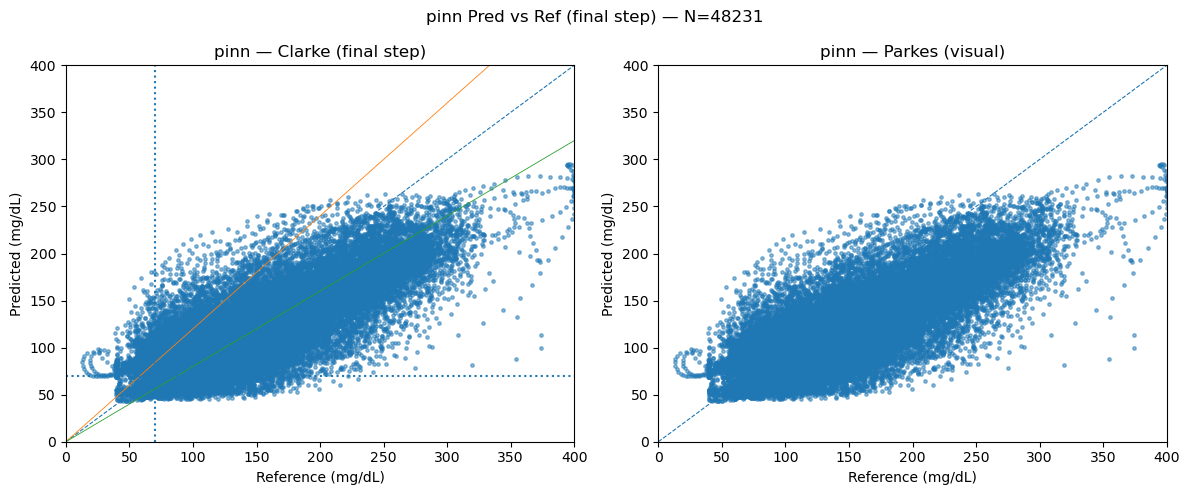


Glycemia detection — pinn (final step):


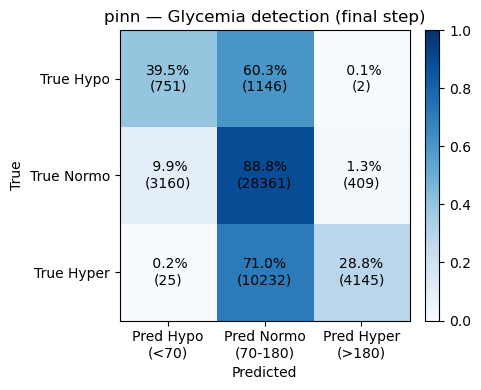

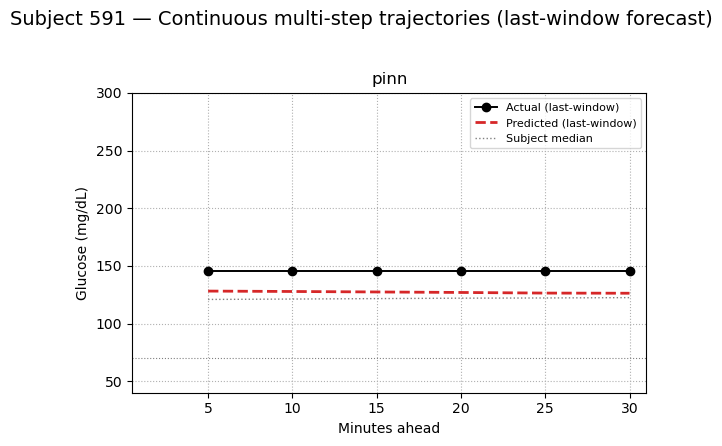

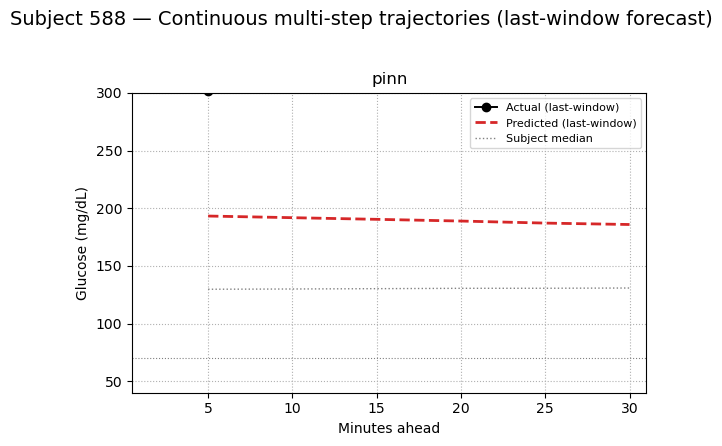

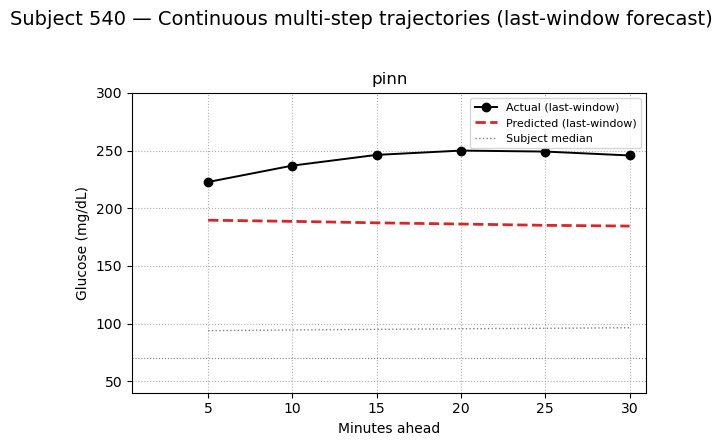

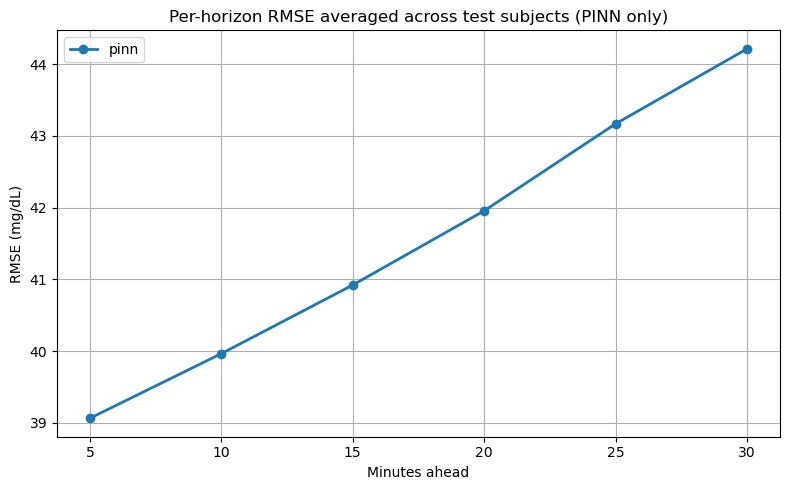


Done. Notes:
- TG now follows TG = PH - delay*dt (median across windows).
- For windows with no timing information (constant signals) TG is set to 0.
- Higher TG (closer to PH) means better timing alignment; lower TG means larger timing misalignment.


In [9]:
# Replacement Evaluation cell (full) with updated Temporal Gain metric per your description
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from collections import Counter
import math
from scipy.signal import correlate

# --------------------------
# Helpers (scaler inversion, glycemia classes, metrics)
# --------------------------
def inv_cgm_with_cg_scaler(y_scaled):
    """y_scaled: array shape (..., N_OUT) or (..., N_OUT, 1) -> returns same shape in mg/dL"""
    if y_scaled is None or np.asarray(y_scaled).size == 0:
        return np.array([]).reshape(0, N_OUT)
    arr = np.asarray(y_scaled)
    if arr.ndim == 3 and arr.shape[-1] == 1:
        arr = arr.reshape(arr.shape[0], arr.shape[1])
    flat = arr.reshape(-1, 1)
    inv = cg_scaler.inverse_transform(flat).reshape(-1, N_OUT)
    return inv

HYPO = 70.0; HYPER = 180.0
def glycemia_class(x):
    x = np.asarray(x).reshape(-1)
    cls = np.full(x.shape, -1, dtype=int)
    cls[x < HYPO] = 0
    cls[(x >= HYPO) & (x <= HYPER)] = 1
    cls[x > HYPER] = 2
    return cls

# ---------- Updated Temporal Gain (TG) implementation ----------
def temporal_gain(y_true, y_pred, prediction_horizon):
    """
    Compute Temporal Gain (TG) following the description:
      - For each forecast window (length = horizon steps), compute cross-correlation between measured
        and predicted horizon-length vectors.
      - Restrict allowed delay tau to [0 .. max_lag_steps] where max_lag_steps = prediction_horizon / dt.
      - Find tau that maximizes abs(cross_corr). Convert tau to minutes: tau_minutes = tau * dt.
      - TG_window = prediction_horizon - tau_minutes.
      - Aggregate windows by median and return TG (minutes), clipped to [0, prediction_horizon].
    Inputs:
      y_true: array shape (n_windows, horizon) OR (n_windows*horizon,) that can be reshaped
      y_pred: same shape as y_true
      prediction_horizon: minutes (e.g., 30)
    Returns:
      median_TG_minutes (int)
    Notes:
      - If a window has very low variance (constant), it is considered uninformative and TG_window = 0.
      - This implementation follows the paper's definition TG = PH - delay * dt.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # infer horizon in steps and dt in minutes
    # prefer global N_OUT if available
    if 'N_OUT' in globals():
        horizon = int(N_OUT)
    else:
        # fallback: assume dt = 5 and compute horizon
        horizon = int(prediction_horizon // 5) or 1
    dt_minutes = float(prediction_horizon) / float(horizon)  # e.g., 30/6 = 5

    # reshape if flattened inputs were provided
    if y_true.ndim == 1 and y_pred.ndim == 1 and (y_true.size % horizon == 0) and (y_pred.size % horizon == 0):
        try:
            y_true = y_true.reshape(-1, horizon)
            y_pred = y_pred.reshape(-1, horizon)
        except Exception:
            return int(prediction_horizon)

    # check shapes
    if y_true.ndim != 2 or y_pred.ndim != 2 or y_true.shape[1] != y_pred.shape[1]:
        # cannot compute TG meaningfully
        return int(prediction_horizon)

    n_windows, L = y_true.shape
    max_lag_steps = int(prediction_horizon // dt_minutes)  # should equal horizon typically
    # ensure integer bounds
    max_lag_steps = min(max_lag_steps, L - 1)

    tg_windows = []
    for i in range(n_windows):
        t = y_true[i].astype(float)
        p = y_pred[i].astype(float)

        # Skip windows with NaNs entirely
        if np.all(np.isnan(t)) or np.all(np.isnan(p)):
            tg_windows.append(0)
            continue

        # If true or predicted horizon is (nearly) constant: uninformative for cross-correlation
        if np.nanstd(t) < 1e-8 or np.nanstd(p) < 1e-8:
            # treat as no timing information -> TG = 0 (as per your preference; persistence thus gets 0)
            tg_windows.append(0)
            continue

        # center signals
        t0 = t - np.nanmean(t)
        p0 = p - np.nanmean(p)

        # full cross-correlation and lags: -(L-1) .. (L-1)
        cc = correlate(t0, p0, mode='full')
        full_lags = np.arange(-L + 1, L)

        # allow only non-negative delays up to max_lag_steps
        valid_mask = (full_lags >= 0) & (full_lags <= max_lag_steps)
        valid_lags = full_lags[valid_mask]
        valid_cc   = cc[valid_mask]

        if valid_cc.size == 0:
            # no valid cross-correlation region -> worst-case
            tg_windows.append(0)
            continue

        # find delay (in steps) that maximizes abs(cross-corr)
        idx = np.argmax(np.abs(valid_cc))
        delay_steps = int(valid_lags[idx])
        delay_minutes = delay_steps * dt_minutes
        tg_val = prediction_horizon - delay_minutes
        # clip to [0, prediction_horizon]
        tg_val = max(0.0, min(float(prediction_horizon), float(tg_val)))
        tg_windows.append(tg_val)

    if len(tg_windows) == 0:
        return int(prediction_horizon)
    # aggregate by median for robustness
    tg_median = float(np.median(tg_windows))
    return int(round(tg_median))

# --- other metrics unchanged ---
def g_mean(y_true, y_pred):
    from sklearn.metrics import recall_score
    t = glycemia_class(y_true); p = glycemia_class(y_pred)
    recalls = recall_score(t, p, average=None, zero_division=0)
    recalls = np.where(recalls == 0, 1e-10, recalls)
    return float(np.exp(np.mean(np.log(recalls))))

def glucose_weighted_rmse(y_true, y_pred):
    y_true = np.asarray(y_true).flatten(); y_pred = np.asarray(y_pred).flatten()
    if y_true.size == 0:
        return np.nan
    w = np.maximum(y_true, 0.0)
    if w.sum() == 0:
        w = np.ones_like(w)
    w = w / w.sum()
    return math.sqrt(np.sum(w * (y_true - y_pred)**2))

def glucose_weighted_mae(y_true, y_pred):
    y_true = np.asarray(y_true).flatten(); y_pred = np.asarray(y_pred).flatten()
    if y_true.size == 0:
        return np.nan
    w = np.maximum(y_true, 0.0)
    if w.sum() == 0:
        w = np.ones_like(w)
    w = w / w.sum()
    return np.sum(w * np.abs(y_true - y_pred))

# Clarke/Parkes fallback (fast)
def clarke_zone_for_point(ref, pred):
    if np.isnan(ref) or np.isnan(pred): return None
    if (ref >= 70 and abs(pred - ref) <= 0.2 * ref) or (ref < 70 and abs(pred - ref) <= 20): return 'A'
    if (pred >= 330 and ref <= 50) or (pred <= 50 and ref >= 330): return 'E'
    if ref < 70 and pred >= 180: return 'C'
    if ref >= 180 and pred < 70: return 'D'
    return 'B'
def parkes_zone_for_point(ref, pred):
    if np.isnan(ref) or np.isnan(pred): return None
    err = pred - ref; rel_err = abs(err) / max(ref,1.0)
    if (ref < 70 and abs(err) <= 15) or (ref >= 70 and rel_err <= 0.2): return 'A'
    if rel_err <= 0.35: return 'B'
    if (ref < 70 and pred > 180) or (ref > 180 and pred < 70): return 'D'
    if rel_err > 0.6: return 'E'
    return 'C'

# --------------------------
# Prepare batched predictions for the PINN model across all test subjects only
# (ONLY PINN is evaluated here)
# --------------------------
models = {
    'pinn': lstm_predict_on_subject
}

def ml_corrector_predict_fast(sid):
    info = per_subject_test.get(sid, None)
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT, 1))
    Xs = info['X']
    resid_scaled = model_corr.predict(Xs, batch_size=128)
    subj = per_subject[sid]
    n_windows = Xs.shape[0]
    G_inits = subj['CGM_smoothed'].values[N_IN-1 : N_IN-1 + n_windows]
    bolus_mat = np.zeros((n_windows, N_OUT))
    carbs_mat  = np.zeros((n_windows, N_OUT))
    for w in range(n_windows):
        start = N_IN + w
        bolus_mat[w, :] = subj['bolus'].values[start:start+N_OUT]
        carbs_mat[w, :] = subj['carbs'].values[start:start+N_OUT]
    p1, p2, p3, k_i, Gb = bergman_model['params']
    dt_scale = (5.0 / 5.0)
    berg_preds = np.zeros((n_windows, N_OUT))
    G = G_inits.copy().astype(float)
    I = np.zeros(n_windows)
    for t in range(N_OUT):
        I = I * math.exp(-k_i) + bolus_mat[:, t]
        meal_effect = p3 * carbs_mat[:, t]
        dG = -p1 * (G - Gb) - p2 * I + meal_effect
        G = G + dG * dt_scale
        berg_preds[:, t] = G
    berg_preds_scaled = cg_scaler.transform(berg_preds.reshape(-1,1)).reshape(-1, N_OUT)
    corrected_scaled = berg_preds_scaled + resid_scaled
    return corrected_scaled.reshape(n_windows, N_OUT, 1)

# --------------------------
# Build arrays across ALL test windows for the PINN model (batched per subject)
# --------------------------
all_results = {}
for mname, mpredict in models.items():
    Ys = []
    for sid, info in per_subject_test.items():
        X_test = info['X']
        if X_test.shape[0] == 0:
            continue
        yhat_scaled = mpredict(sid)
        yhat_scaled = np.asarray(yhat_scaled)
        if yhat_scaled.ndim == 3 and yhat_scaled.shape[-1] == 1:
            yhat_scaled = yhat_scaled.reshape(yhat_scaled.shape[0], yhat_scaled.shape[1])
        yhat_mg = inv_cgm_with_cg_scaler(yhat_scaled)
        Ys.append(yhat_mg)
    all_results[mname] = np.vstack(Ys) if len(Ys) else np.zeros((0, N_OUT))

# Build ground-truth (all windows)
y_true_all_windows = []
for sid, info in per_subject_test.items():
    y_test = info['y']
    if y_test.shape[0] == 0:
        continue
    y_true_mg = inv_cgm_with_cg_scaler(y_test.reshape(-1, N_OUT))
    y_true_all_windows.append(y_true_mg)
if len(y_true_all_windows) == 0:
    raise RuntimeError("No test windows found.")
y_true_all = np.vstack(y_true_all_windows)

# --------------------------
# Metrics (per-horizon and final-step)
# --------------------------
horiz_steps = np.arange(1, N_OUT+1) * 5
print("\n=== Per-horizon RMSE / MAE for the PINN model ===")
per_horizon = {}
for mname, ypred_all in all_results.items():
    if ypred_all.size == 0:
        print(f"Model {mname}: no predictions")
        continue
    rmse_h = []
    mae_h = []
    for h in range(N_OUT):
        y_t = y_true_all[:, h]
        y_p = ypred_all[:, h]
        rmse_h.append(np.sqrt(mean_squared_error(y_t, y_p)))
        mae_h.append(mean_absolute_error(y_t, y_p))
    per_horizon[mname] = {'rmse': rmse_h, 'mae': mae_h}
    print(f"\nModel: {mname}")
    print("Horizon (min):", list(horiz_steps))
    print("RMSE (mg/dL): ", [round(v,2) for v in rmse_h])
    print("MAE  (mg/dL): ", [round(v,2) for v in mae_h])

print("\n=== Final-step aggregated metrics (30 min) ===")
for mname, ypred_all in all_results.items():
    if ypred_all.size == 0:
        continue
    ref = y_true_all[:, -1]; pred = ypred_all[:, -1]
    rmse_val = np.sqrt(mean_squared_error(ref, pred))
    mae_val  = mean_absolute_error(ref, pred)
    gw_rmse = glucose_weighted_rmse(ref, pred)
    gw_mae  = glucose_weighted_mae(ref, pred)
    # compute TG using multi-step arrays and the paper definition TG = PH - delay*dt (median across windows)
    tg = temporal_gain(y_true_all, ypred_all, prediction_horizon=5*N_OUT)
    gm = g_mean(ref, pred)
    print(f"\nModel: {mname}")
    print(f"  windows: {len(ref)}")
    print(f"  RMSE: {rmse_val:.3f}  MAE: {mae_val:.3f}")
    print(f"  Glucose-weighted RMSE: {gw_rmse:.3f}  Glucose-weighted MAE: {gw_mae:.3f}")
    print(f"  Temporal gain (min): {tg}   G-Mean: {gm:.4f}")

# --------------------------
# Clarke & Parkes (fallback) + scatter plots (final step) for PINN only
# --------------------------
for mname, ypred_all in all_results.items():
    if ypred_all.size == 0:
        continue
    ref = y_true_all[:, -1]; pred = ypred_all[:, -1]
    cz = [clarke_zone_for_point(r,p) for r,p in zip(ref, pred)]
    pz = [parkes_zone_for_point(r,p) for r,p in zip(ref, pred)]
    c_counts = dict(Counter(cz)); p_counts = dict(Counter(pz)); total = len(ref)
    print(f"\n{mname} Clarke zones: ", {k:(c_counts[k], round(100*c_counts[k]/total,2)) for k in c_counts})
    print(f"{mname} Parkes zones : ", {k:(p_counts[k], round(100*p_counts[k]/total,2)) for k in p_counts})

    fig, ax = plt.subplots(1,2, figsize=(12,5))
    ax0 = ax[0]
    ax0.scatter(ref, pred, s=6, alpha=0.5)
    ax0.plot([0,400],[0,400],'--', linewidth=0.8)
    xs = np.linspace(0,400,100); ax0.plot(xs, 1.2*xs, linewidth=0.6); ax0.plot(xs, 0.8*xs, linewidth=0.6)
    ax0.axvline(70, linestyle=':'); ax0.axhline(70, linestyle=':')
    ax0.set_xlim(0,400); ax0.set_ylim(0,400)
    ax0.set_xlabel('Reference (mg/dL)'); ax0.set_ylabel('Predicted (mg/dL)')
    ax0.set_title(f"{mname} — Clarke (final step)")

    ax1 = ax[1]
    ax1.scatter(ref, pred, s=6, alpha=0.5)
    ax1.plot([0,400],[0,400],'--', linewidth=0.8)
    ax1.set_xlim(0,400); ax1.set_ylim(0,400)
    ax1.set_xlabel('Reference (mg/dL)'); ax1.set_ylabel('Predicted (mg/dL)')
    ax1.set_title(f"{mname} — Parkes (visual)")
    plt.suptitle(f"{mname} Pred vs Ref (final step) — N={total}")
    plt.tight_layout()
    plt.show()

# --------------------------
# Glycemia detection confusion matrix for PINN (final step)
# --------------------------
def compute_glycemia_confusion(y_true, y_pred):
    y_t = np.asarray(y_true).reshape(-1); y_p = np.asarray(y_pred).reshape(-1)
    mask = np.isfinite(y_t) & np.isfinite(y_p)
    y_t = y_t[mask]; y_p = y_p[mask]
    counts = np.zeros((3,3), dtype=int)
    if y_t.size == 0:
        return counts, np.full_like(counts, np.nan, dtype=float)
    tcls = glycemia_class(y_t); pcls = glycemia_class(y_p)
    for t,p in zip(tcls, pcls):
        if 0<=t<=2 and 0<=p<=2:
            counts[t,p] += 1
    pct = np.full_like(counts, np.nan, dtype=float)
    for i in range(3):
        s = counts[i].sum()
        if s>0:
            pct[i,:] = counts[i,:] / float(s)
    return counts, pct

def plot_confusion_heatmaps(counts, pct, title=""):
    fig, ax = plt.subplots(1,1, figsize=(5,4))
    im = ax.imshow(pct, vmin=0.0, vmax=1.0, cmap='Blues', interpolation='nearest')
    ax.set_xticks(np.arange(3)); ax.set_yticks(np.arange(3))
    labels = ['Pred Hypo\n(<70)','Pred Normo\n(70-180)','Pred Hyper\n(>180)']
    ax.set_xticklabels(labels); ax.set_yticklabels(['True Hypo','True Normo','True Hyper'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    for i in range(3):
        for j in range(3):
            c = counts[i,j]; p = pct[i,j]
            if np.isnan(p):
                txt = "n/a\n(0)"
            else:
                txt = f"{p*100:4.1f}%\n({c})"
            ax.text(j, i, txt, ha='center', va='center', color='black', fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()

for mname, ypred_all in all_results.items():
    if ypred_all.size == 0: continue
    counts, pct = compute_glycemia_confusion(y_true_all[:, -1], ypred_all[:, -1])
    print(f"\nGlycemia detection — {mname} (final step):")
    plot_confusion_heatmaps(counts, pct, title=f"{mname} — Glycemia detection (final step)")

# --------------------------
# UPDATED PLOTTING SECTION (very simple continuous multi-step trajectories)
# Only PINN is plotted here.
# --------------------------
model_order = ['pinn']
n_models = len(model_order)
selected_sids = list(per_subject_test.keys())[:3]  # same first 3 test subjects
t_h = np.arange(1, N_OUT+1) * 5  # [5,10,...,30] minutes ahead

if len(selected_sids) == 0:
    print("No test subjects available for plotting.")
else:
    for sid in selected_sids:
        info = per_subject_test[sid]
        X_test = info['X']        # shape (n_windows, N_IN, feats)
        y_test = info['y']        # shape (n_windows, N_OUT, 1) or (n_windows, N_OUT)
        if X_test.shape[0] == 0:
            continue

        # select the last available window (most recent) to produce a single continuous forecast
        last_idx = -1

        # prepare actual multi-step targets (mg/dL) and pick last window's trajectory
        y_test_arr = np.asarray(y_test)
        if y_test_arr.ndim == 3 and y_test_arr.shape[-1] == 1:
            y_test_flat_scaled = y_test_arr.reshape(y_test_arr.shape[0], y_test_arr.shape[1])
        else:
            y_test_flat_scaled = y_test_arr
        y_test_mg = inv_cgm_with_cg_scaler(y_test_flat_scaled)  # (n_windows, N_OUT)
        actual_traj = y_test_mg[last_idx]                      # (N_OUT,)

        # create figure (one subplot per model — here only PINN)
        fig, axs = plt.subplots(1, n_models, figsize=(6 * n_models, 4.5), sharey=True)
        if n_models == 1:
            axs = [axs]
        fig.suptitle(f"Subject {sid} — Continuous multi-step trajectories (last-window forecast)", fontsize=14)

        for i_m, mname in enumerate(model_order):
            ax = axs[i_m]

            # get model predictions for this subject (batched), then take last window's prediction
            yhat_scaled_all = models[mname](sid)
            yhat_scaled_all = np.asarray(yhat_scaled_all)
            if yhat_scaled_all.size == 0:
                ax.text(0.5, 0.5, "no preds", ha='center', va='center')
                ax.set_title(mname)
                continue
            if yhat_scaled_all.ndim == 3 and yhat_scaled_all.shape[-1] == 1:
                yhat_scaled_all = yhat_scaled_all.reshape(yhat_scaled_all.shape[0], yhat_scaled_all.shape[1])
            yhat_mg_all = inv_cgm_with_cg_scaler(yhat_scaled_all)  # (n_windows, N_OUT)
            pred_traj = yhat_mg_all[last_idx]                      # (N_OUT,)

            # plot actual multi-step trajectory (black '-o-')
            ax.plot(t_h, actual_traj, '-o', color='black', markersize=6, linewidth=1.4, label='Actual (last-window)')
            # plot predicted multi-step trajectory (colored dashed)
            color = 'tab:blue' if mname=='lstm' else 'tab:red'
            ax.plot(t_h, pred_traj, '--', color=color, linewidth=2.0, label='Predicted (last-window)')

            # optionally also plot subject-level median prediction (thin)
            med = np.nanmedian(yhat_mg_all, axis=0)
            ax.plot(t_h, med, ':', color='gray', linewidth=1.0, label='Subject median')

            ax.set_title(mname)
            ax.set_xlabel('Minutes ahead')
            if i_m == 0:
                ax.set_ylabel('Glucose (mg/dL)')
            ax.set_xticks(t_h)
            ax.set_xlim(0.5, t_h[-1] + 1)
            ax.axhline(HYPO, color='gray', linestyle=':', linewidth=0.8)
            ax.set_ylim(40, 300)
            ax.grid(True, linestyle=':')
            ax.legend(fontsize=8)

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

# Combined summary plot: per-horizon RMSE averaged across subjects (PINN only)
model_names = list(all_results.keys())
per_subject_rmse = {m: [] for m in model_names}
for sid, info in per_subject_test.items():
    y_test = info['y']
    if y_test.shape[0] == 0:
        continue
    y_true_mg = inv_cgm_with_cg_scaler(y_test.reshape(-1, N_OUT))  # (n_windows, N_OUT)
    for m in model_names:
        yhat_scaled = models[m](sid)
        if np.asarray(yhat_scaled).size == 0:
            continue
        yhat_scaled = np.asarray(yhat_scaled)
        if yhat_scaled.ndim == 3 and yhat_scaled.shape[-1] == 1:
            yhat_scaled = yhat_scaled.reshape(yhat_scaled.shape[0], yhat_scaled.shape[1])
        yhat_mg = inv_cgm_with_cg_scaler(yhat_scaled)
        rmse_per_h = [np.sqrt(mean_squared_error(y_true_mg[:,h], yhat_mg[:,h])) for h in range(N_OUT)]
        per_subject_rmse[m].append(rmse_per_h)

plt.figure(figsize=(8,5))
for m in model_names:
    subj_rmses = np.array(per_subject_rmse[m]) if len(per_subject_rmse[m])>0 else np.zeros((0, N_OUT))
    if subj_rmses.size == 0:
        continue
    mean_rmse = np.nanmean(subj_rmses, axis=0)
    plt.plot(t_h, mean_rmse, '-o', label=m, linewidth=2)
plt.xticks(t_h)
plt.xlabel('Minutes ahead'); plt.ylabel('RMSE (mg/dL)')
plt.title('Per-horizon RMSE averaged across test subjects (PINN only)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

print("\nDone. Notes:")
print("- TG now follows TG = PH - delay*dt (median across windows).")
print("- For windows with no timing information (constant signals) TG is set to 0.")
print("- Higher TG (closer to PH) means better timing alignment; lower TG means larger timing misalignment.")


124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

=== Per-horizon RMSE / MAE for each model ===

Model: persistence
Horizon (min): [5, 10, 15, 20, 25, 30]
RMSE (mg/dL):  [4.79, 9.42, 13.75, 17.73, 21.35, 24.64]
MAE  (mg/dL):  [3.32, 6.53, 9.56, 12.37, 14.95, 17.34]

Model: bergman
Horizon (min): [5, 10, 15, 20, 25, 30]
RMSE (mg/dL):  [4.79, 9.38, 13.64, 17.52, 21.03, 24.18]
MAE  (mg/dL):  [3.35, 6.57, 9.58, 12.36, 14.89, 17.2]

Model: lstm
Horizon (min): [5, 10, 15, 20, 25, 30]
RMSE (mg/dL):  [35.0, 35.67, 36.5, 37.43, 38.41, 39.41]
MAE  (mg/dL):  [28.37, 28.89, 29.54, 30.27, 31.03, 31.8]

Model: ml_corrector
Horizon (min): [5, 10, 15, 20, 25, 30]
RMSE (mg/dL):  [1.54, 3.76, 6.84, 10.47, 14.19, 17.69]
MAE  (mg/dL):  [1.13, 2.63, 4.79, 7.36, 9.99, 12.56]

=== Final-step aggregated metrics (30 min) ===

Model: persistence
  windows: 48231
  RMSE: 24.644  MAE: 17.336
  Glucose-weighted RMSE: 25.586  Glucose-weighted

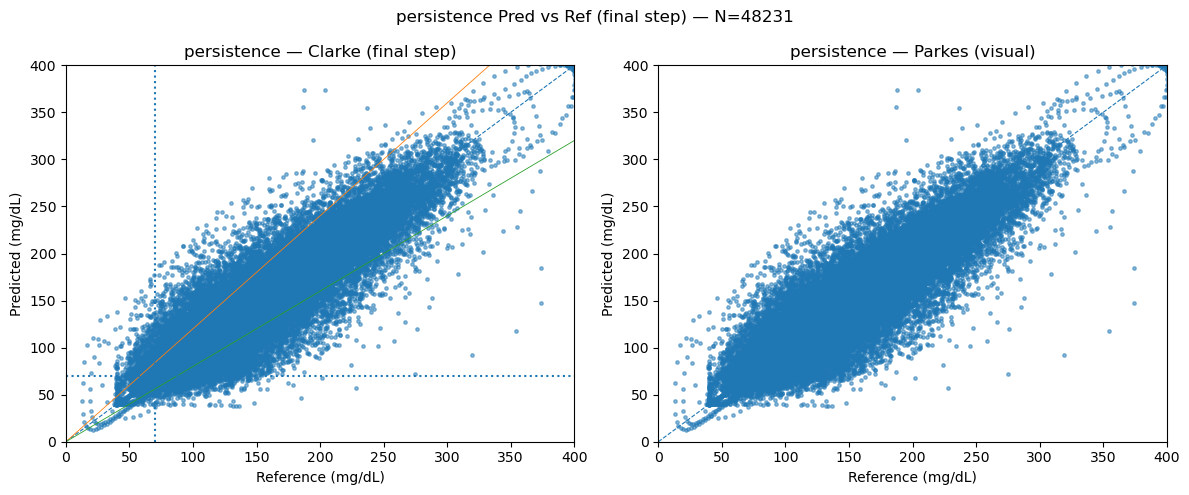


bergman Clarke zones:  {'A': (39105, 81.08), 'B': (9124, 18.92), 'D': (2, 0.0)}
bergman Parkes zones :  {'A': (38899, 80.65), 'B': (6212, 12.88), 'C': (2481, 5.14), 'E': (637, 1.32), 'D': (2, 0.0)}


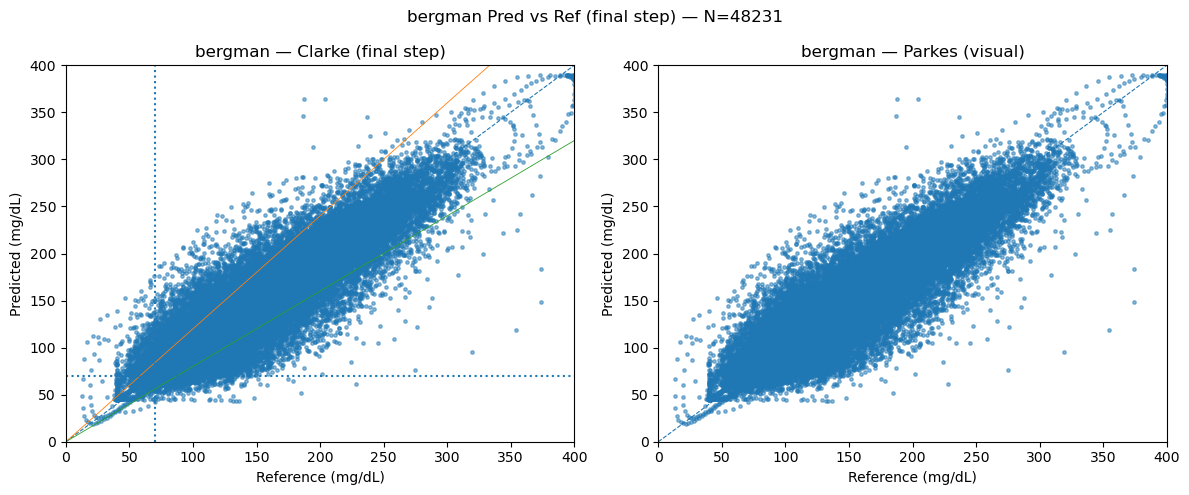


lstm Clarke zones:  {'A': (26851, 55.67), 'B': (21380, 44.33)}
lstm Parkes zones :  {'A': (26839, 55.65), 'B': (10967, 22.74), 'C': (5547, 11.5), 'E': (4878, 10.11)}


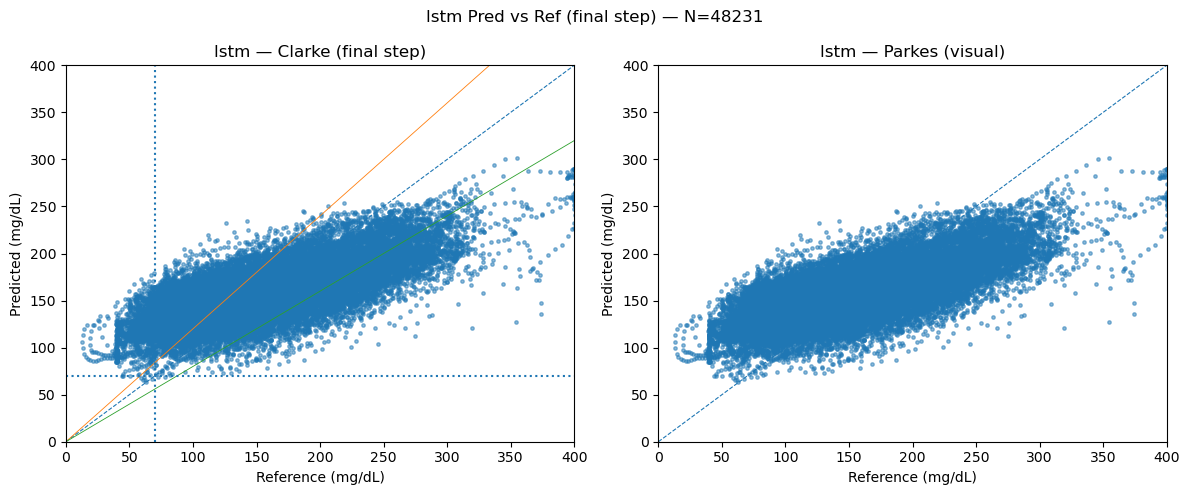


ml_corrector Clarke zones:  {'A': (42839, 88.82), 'B': (5391, 11.18), 'C': (1, 0.0)}
ml_corrector Parkes zones :  {'A': (42556, 88.23), 'B': (4144, 8.59), 'E': (254, 0.53), 'C': (1276, 2.65), 'D': (1, 0.0)}


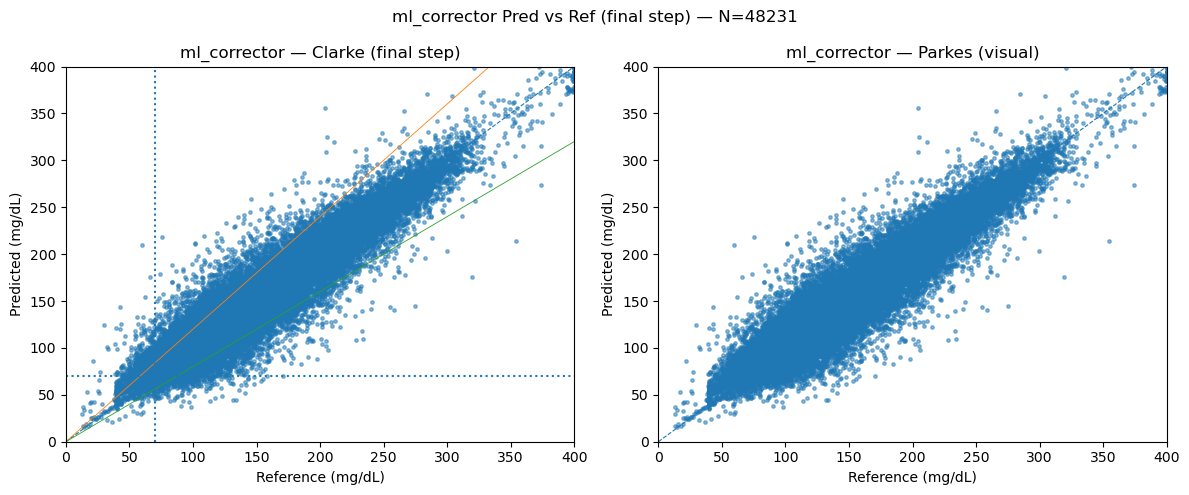


Glycemia detection — persistence (final step):


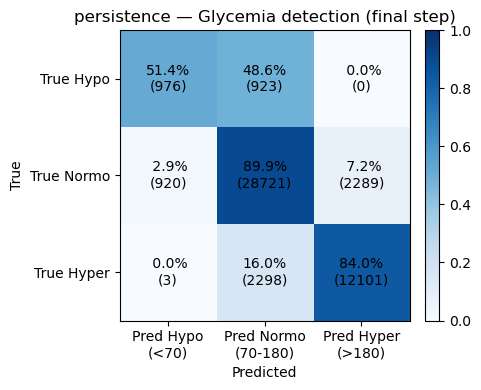


Glycemia detection — bergman (final step):


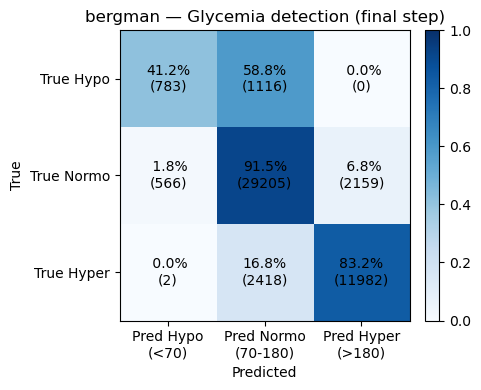


Glycemia detection — lstm (final step):


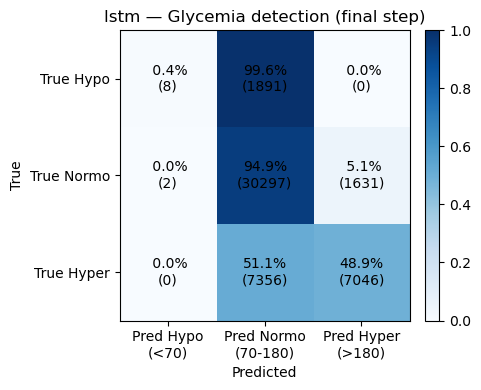


Glycemia detection — ml_corrector (final step):


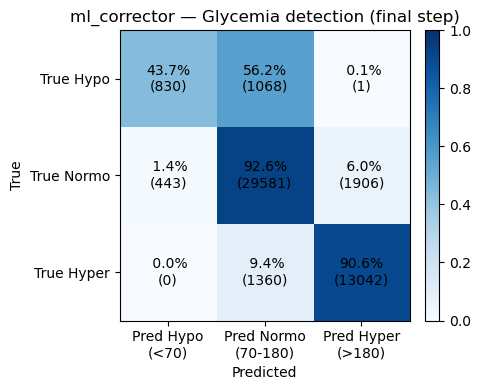

124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


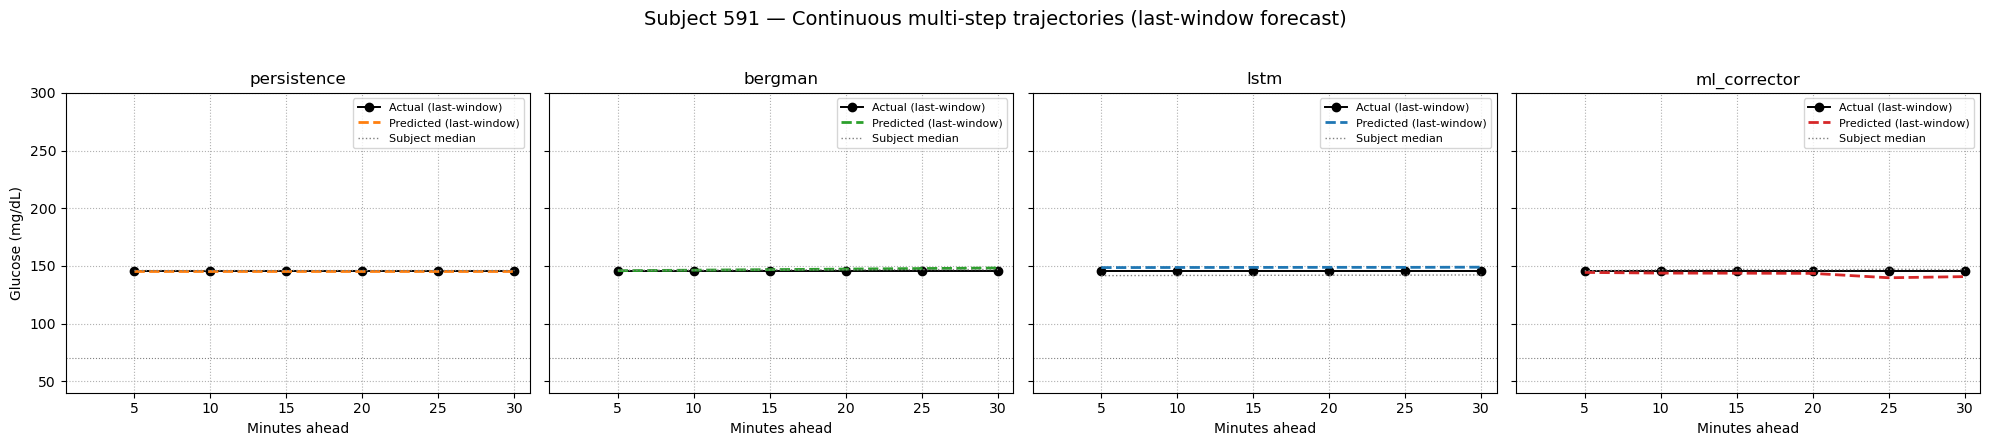

126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


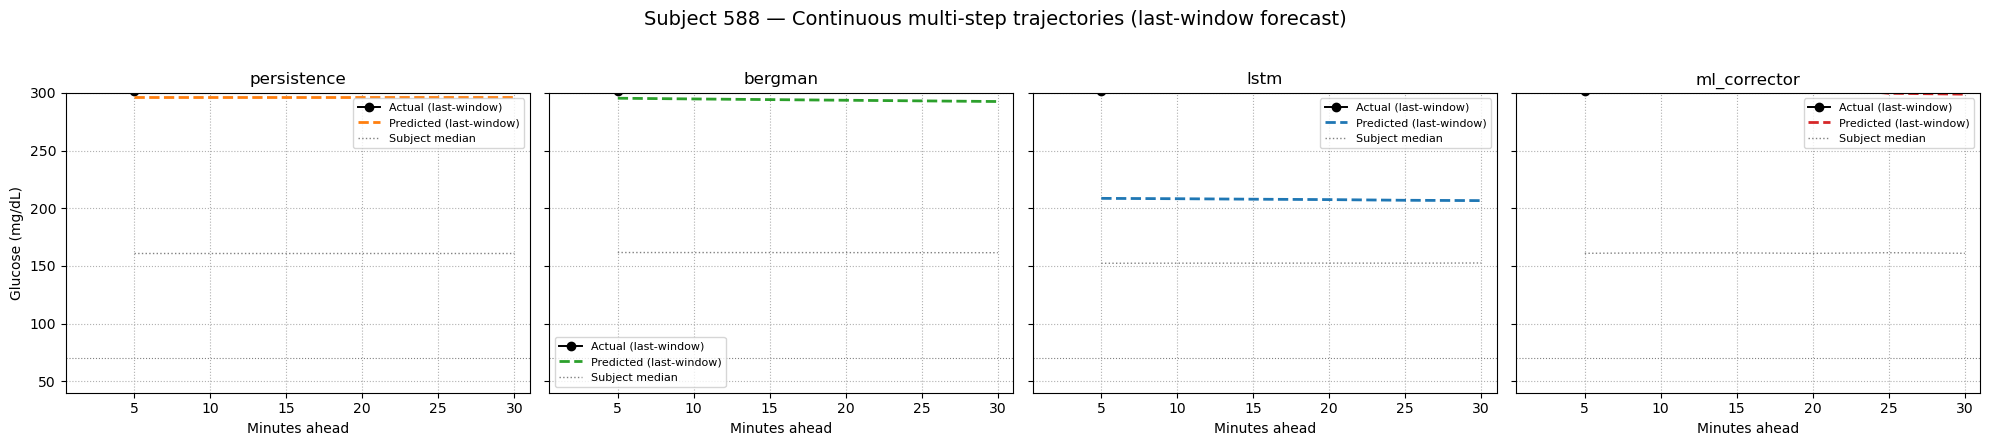

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


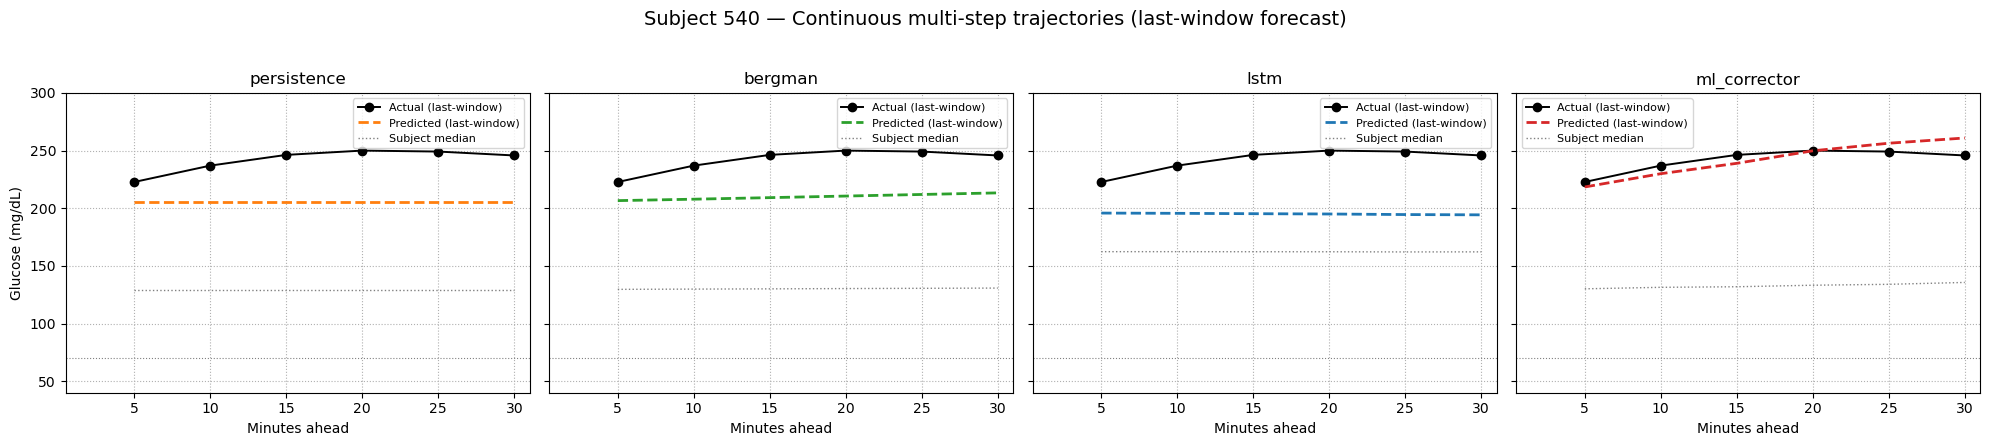

124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


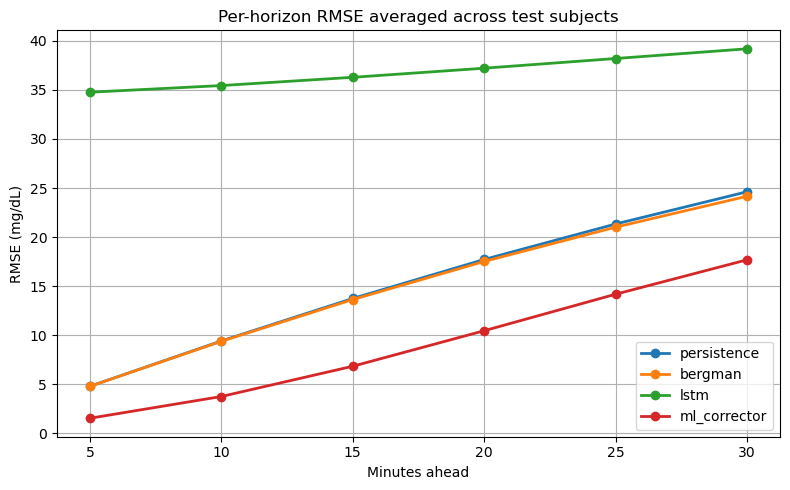


Done. Notes:
- TG now follows TG = PH - delay*dt (median across windows).
- For windows with no timing information (constant signals) TG is set to 0 (persistence will return TG~0).
- Higher TG (closer to PH) means better timing alignment; lower TG means larger timing misalignment.


In [5]:
# Replacement Evaluation cell (full) with updated Temporal Gain metric per your description
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from collections import Counter
import math
from scipy.signal import correlate

# --------------------------
# Helpers (scaler inversion, glycemia classes, metrics)
# --------------------------
def inv_cgm_with_cg_scaler(y_scaled):
    """y_scaled: array shape (..., N_OUT) or (..., N_OUT, 1) -> returns same shape in mg/dL"""
    if y_scaled is None or np.asarray(y_scaled).size == 0:
        return np.array([]).reshape(0, N_OUT)
    arr = np.asarray(y_scaled)
    if arr.ndim == 3 and arr.shape[-1] == 1:
        arr = arr.reshape(arr.shape[0], arr.shape[1])
    flat = arr.reshape(-1, 1)
    inv = cg_scaler.inverse_transform(flat).reshape(-1, N_OUT)
    return inv

HYPO = 70.0; HYPER = 180.0
def glycemia_class(x):
    x = np.asarray(x).reshape(-1)
    cls = np.full(x.shape, -1, dtype=int)
    cls[x < HYPO] = 0
    cls[(x >= HYPO) & (x <= HYPER)] = 1
    cls[x > HYPER] = 2
    return cls

# ---------- Updated Temporal Gain (TG) implementation ----------
def temporal_gain(y_true, y_pred, prediction_horizon):
    """
    Compute Temporal Gain (TG) following the description:
      - For each forecast window (length = horizon steps), compute cross-correlation between measured
        and predicted horizon-length vectors.
      - Restrict allowed delay tau to [0 .. max_lag_steps] where max_lag_steps = prediction_horizon / dt.
      - Find tau that maximizes abs(cross_corr). Convert tau to minutes: tau_minutes = tau * dt.
      - TG_window = prediction_horizon - tau_minutes.
      - Aggregate windows by median and return TG (minutes), clipped to [0, prediction_horizon].
    Inputs:
      y_true: array shape (n_windows, horizon) OR (n_windows*horizon,) that can be reshaped
      y_pred: same shape as y_true
      prediction_horizon: minutes (e.g., 30)
    Returns:
      median_TG_minutes (int)
    Notes:
      - If a window has very low variance (constant), it is considered uninformative and TG_window = 0.
      - This implementation follows the paper's definition TG = PH - delay * dt.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # infer horizon in steps and dt in minutes
    # prefer global N_OUT if available
    if 'N_OUT' in globals():
        horizon = int(N_OUT)
    else:
        # fallback: assume dt = 5 and compute horizon
        horizon = int(prediction_horizon // 5) or 1
    dt_minutes = float(prediction_horizon) / float(horizon)  # e.g., 30/6 = 5

    # reshape if flattened inputs were provided
    if y_true.ndim == 1 and y_pred.ndim == 1 and (y_true.size % horizon == 0) and (y_pred.size % horizon == 0):
        try:
            y_true = y_true.reshape(-1, horizon)
            y_pred = y_pred.reshape(-1, horizon)
        except Exception:
            return int(prediction_horizon)

    # check shapes
    if y_true.ndim != 2 or y_pred.ndim != 2 or y_true.shape[1] != y_pred.shape[1]:
        # cannot compute TG meaningfully
        return int(prediction_horizon)

    n_windows, L = y_true.shape
    max_lag_steps = int(prediction_horizon // dt_minutes)  # should equal horizon typically
    # ensure integer bounds
    max_lag_steps = min(max_lag_steps, L - 1)

    tg_windows = []
    for i in range(n_windows):
        t = y_true[i].astype(float)
        p = y_pred[i].astype(float)

        # Skip windows with NaNs entirely
        if np.all(np.isnan(t)) or np.all(np.isnan(p)):
            tg_windows.append(0)
            continue

        # If true or predicted horizon is (nearly) constant: uninformative for cross-correlation
        if np.nanstd(t) < 1e-8 or np.nanstd(p) < 1e-8:
            # treat as no timing information -> TG = 0 (as per your preference; persistence thus gets 0)
            tg_windows.append(0)
            continue

        # center signals
        t0 = t - np.nanmean(t)
        p0 = p - np.nanmean(p)

        # full cross-correlation and lags: -(L-1) .. (L-1)
        cc = correlate(t0, p0, mode='full')
        full_lags = np.arange(-L + 1, L)

        # allow only non-negative delays up to max_lag_steps
        valid_mask = (full_lags >= 0) & (full_lags <= max_lag_steps)
        valid_lags = full_lags[valid_mask]
        valid_cc   = cc[valid_mask]

        if valid_cc.size == 0:
            # no valid cross-correlation region -> worst-case
            tg_windows.append(0)
            continue

        # find delay (in steps) that maximizes abs(cross-corr)
        idx = np.argmax(np.abs(valid_cc))
        delay_steps = int(valid_lags[idx])
        delay_minutes = delay_steps * dt_minutes
        tg_val = prediction_horizon - delay_minutes
        # clip to [0, prediction_horizon]
        tg_val = max(0.0, min(float(prediction_horizon), float(tg_val)))
        tg_windows.append(tg_val)

    if len(tg_windows) == 0:
        return int(prediction_horizon)
    # aggregate by median for robustness
    tg_median = float(np.median(tg_windows))
    return int(round(tg_median))

# --- other metrics unchanged ---
def g_mean(y_true, y_pred):
    from sklearn.metrics import recall_score
    t = glycemia_class(y_true); p = glycemia_class(y_pred)
    recalls = recall_score(t, p, average=None, zero_division=0)
    recalls = np.where(recalls == 0, 1e-10, recalls)
    return float(np.exp(np.mean(np.log(recalls))))

def glucose_weighted_rmse(y_true, y_pred):
    y_true = np.asarray(y_true).flatten(); y_pred = np.asarray(y_pred).flatten()
    if y_true.size == 0:
        return np.nan
    w = np.maximum(y_true, 0.0)
    if w.sum() == 0:
        w = np.ones_like(w)
    w = w / w.sum()
    return math.sqrt(np.sum(w * (y_true - y_pred)**2))

def glucose_weighted_mae(y_true, y_pred):
    y_true = np.asarray(y_true).flatten(); y_pred = np.asarray(y_pred).flatten()
    if y_true.size == 0:
        return np.nan
    w = np.maximum(y_true, 0.0)
    if w.sum() == 0:
        w = np.ones_like(w)
    w = w / w.sum()
    return np.sum(w * np.abs(y_true - y_pred))

# Clarke/Parkes fallback (fast)
def clarke_zone_for_point(ref, pred):
    if np.isnan(ref) or np.isnan(pred): return None
    if (ref >= 70 and abs(pred - ref) <= 0.2 * ref) or (ref < 70 and abs(pred - ref) <= 20): return 'A'
    if (pred >= 330 and ref <= 50) or (pred <= 50 and ref >= 330): return 'E'
    if ref < 70 and pred >= 180: return 'C'
    if ref >= 180 and pred < 70: return 'D'
    return 'B'
def parkes_zone_for_point(ref, pred):
    if np.isnan(ref) or np.isnan(pred): return None
    err = pred - ref; rel_err = abs(err) / max(ref,1.0)
    if (ref < 70 and abs(err) <= 15) or (ref >= 70 and rel_err <= 0.2): return 'A'
    if rel_err <= 0.35: return 'B'
    if (ref < 70 and pred > 180) or (ref > 180 and pred < 70): return 'D'
    if rel_err > 0.6: return 'E'
    return 'C'

# --------------------------
# Prepare batched predictions for each model across all test subjects
# (unchanged from previously working code)
# --------------------------
models = {
    'persistence': persistence_model['predict'],
    'bergman': bergman_model['predict'],
    'lstm': lambda s: lstm_predict_on_subject(s),
    'ml_corrector': ml_corrector_model['predict']
}

def ml_corrector_predict_fast(sid):
    info = per_subject_test.get(sid, None)
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT, 1))
    Xs = info['X']
    resid_scaled = model_corr.predict(Xs, batch_size=128)
    subj = per_subject[sid]
    n_windows = Xs.shape[0]
    G_inits = subj['CGM_smoothed'].values[N_IN-1 : N_IN-1 + n_windows]
    bolus_mat = np.zeros((n_windows, N_OUT))
    carbs_mat  = np.zeros((n_windows, N_OUT))
    for w in range(n_windows):
        start = N_IN + w
        bolus_mat[w, :] = subj['bolus'].values[start:start+N_OUT]
        carbs_mat[w, :] = subj['carbs'].values[start:start+N_OUT]
    p1, p2, p3, k_i, Gb = bergman_model['params']
    dt_scale = (5.0 / 5.0)
    berg_preds = np.zeros((n_windows, N_OUT))
    G = G_inits.copy().astype(float)
    I = np.zeros(n_windows)
    for t in range(N_OUT):
        I = I * math.exp(-k_i) + bolus_mat[:, t]
        meal_effect = p3 * carbs_mat[:, t]
        dG = -p1 * (G - Gb) - p2 * I + meal_effect
        G = G + dG * dt_scale
        berg_preds[:, t] = G
    berg_preds_scaled = cg_scaler.transform(berg_preds.reshape(-1,1)).reshape(-1, N_OUT)
    corrected_scaled = berg_preds_scaled + resid_scaled
    return corrected_scaled.reshape(n_windows, N_OUT, 1)

models['ml_corrector'] = ml_corrector_predict_fast

# --------------------------
# Build arrays across ALL test windows for each model (batched per subject)
# --------------------------
all_results = {}
for mname, mpredict in models.items():
    Ys = []
    for sid, info in per_subject_test.items():
        X_test = info['X']
        if X_test.shape[0] == 0:
            continue
        yhat_scaled = mpredict(sid)
        yhat_scaled = np.asarray(yhat_scaled)
        if yhat_scaled.ndim == 3 and yhat_scaled.shape[-1] == 1:
            yhat_scaled = yhat_scaled.reshape(yhat_scaled.shape[0], yhat_scaled.shape[1])
        yhat_mg = inv_cgm_with_cg_scaler(yhat_scaled)
        Ys.append(yhat_mg)
    all_results[mname] = np.vstack(Ys) if len(Ys) else np.zeros((0, N_OUT))

# Build ground-truth (all windows)
y_true_all_windows = []
for sid, info in per_subject_test.items():
    y_test = info['y']
    if y_test.shape[0] == 0:
        continue
    y_true_mg = inv_cgm_with_cg_scaler(y_test.reshape(-1, N_OUT))
    y_true_all_windows.append(y_true_mg)
if len(y_true_all_windows) == 0:
    raise RuntimeError("No test windows found.")
y_true_all = np.vstack(y_true_all_windows)

# --------------------------
# Metrics (per-horizon and final-step)
# --------------------------
horiz_steps = np.arange(1, N_OUT+1) * 5
print("\n=== Per-horizon RMSE / MAE for each model ===")
per_horizon = {}
for mname, ypred_all in all_results.items():
    if ypred_all.size == 0:
        print(f"Model {mname}: no predictions")
        continue
    rmse_h = []
    mae_h = []
    for h in range(N_OUT):
        y_t = y_true_all[:, h]
        y_p = ypred_all[:, h]
        rmse_h.append(np.sqrt(mean_squared_error(y_t, y_p)))
        mae_h.append(mean_absolute_error(y_t, y_p))
    per_horizon[mname] = {'rmse': rmse_h, 'mae': mae_h}
    print(f"\nModel: {mname}")
    print("Horizon (min):", list(horiz_steps))
    print("RMSE (mg/dL): ", [round(v,2) for v in rmse_h])
    print("MAE  (mg/dL): ", [round(v,2) for v in mae_h])

print("\n=== Final-step aggregated metrics (30 min) ===")
for mname, ypred_all in all_results.items():
    if ypred_all.size == 0:
        continue
    ref = y_true_all[:, -1]; pred = ypred_all[:, -1]
    rmse_val = np.sqrt(mean_squared_error(ref, pred))
    mae_val  = mean_absolute_error(ref, pred)
    gw_rmse = glucose_weighted_rmse(ref, pred)
    gw_mae  = glucose_weighted_mae(ref, pred)
    # compute TG using multi-step arrays and the paper definition TG = PH - delay*dt (median across windows)
    tg = temporal_gain(y_true_all, ypred_all, prediction_horizon=5*N_OUT)
    gm = g_mean(ref, pred)
    print(f"\nModel: {mname}")
    print(f"  windows: {len(ref)}")
    print(f"  RMSE: {rmse_val:.3f}  MAE: {mae_val:.3f}")
    print(f"  Glucose-weighted RMSE: {gw_rmse:.3f}  Glucose-weighted MAE: {gw_mae:.3f}")
    print(f"  Temporal gain (min): {tg}   G-Mean: {gm:.4f}")

# --------------------------
# Clarke & Parkes (fallback) + scatter plots per model (final step)
# --------------------------
for mname, ypred_all in all_results.items():
    if ypred_all.size == 0:
        continue
    ref = y_true_all[:, -1]; pred = ypred_all[:, -1]
    cz = [clarke_zone_for_point(r,p) for r,p in zip(ref, pred)]
    pz = [parkes_zone_for_point(r,p) for r,p in zip(ref, pred)]
    c_counts = dict(Counter(cz)); p_counts = dict(Counter(pz)); total = len(ref)
    print(f"\n{mname} Clarke zones: ", {k:(c_counts[k], round(100*c_counts[k]/total,2)) for k in c_counts})
    print(f"{mname} Parkes zones : ", {k:(p_counts[k], round(100*p_counts[k]/total,2)) for k in p_counts})

    fig, ax = plt.subplots(1,2, figsize=(12,5))
    ax0 = ax[0]
    ax0.scatter(ref, pred, s=6, alpha=0.5)
    ax0.plot([0,400],[0,400],'--', linewidth=0.8)
    xs = np.linspace(0,400,100); ax0.plot(xs, 1.2*xs, linewidth=0.6); ax0.plot(xs, 0.8*xs, linewidth=0.6)
    ax0.axvline(70, linestyle=':'); ax0.axhline(70, linestyle=':')
    ax0.set_xlim(0,400); ax0.set_ylim(0,400)
    ax0.set_xlabel('Reference (mg/dL)'); ax0.set_ylabel('Predicted (mg/dL)')
    ax0.set_title(f"{mname} — Clarke (final step)")

    ax1 = ax[1]
    ax1.scatter(ref, pred, s=6, alpha=0.5)
    ax1.plot([0,400],[0,400],'--', linewidth=0.8)
    ax1.set_xlim(0,400); ax1.set_ylim(0,400)
    ax1.set_xlabel('Reference (mg/dL)'); ax1.set_ylabel('Predicted (mg/dL)')
    ax1.set_title(f"{mname} — Parkes (visual)")
    plt.suptitle(f"{mname} Pred vs Ref (final step) — N={total}")
    plt.tight_layout()
    plt.show()

# --------------------------
# Glycemia detection confusion matrices for each model (final step)
# --------------------------
def compute_glycemia_confusion(y_true, y_pred):
    y_t = np.asarray(y_true).reshape(-1); y_p = np.asarray(y_pred).reshape(-1)
    mask = np.isfinite(y_t) & np.isfinite(y_p)
    y_t = y_t[mask]; y_p = y_p[mask]
    counts = np.zeros((3,3), dtype=int)
    if y_t.size == 0:
        return counts, np.full_like(counts, np.nan, dtype=float)
    tcls = glycemia_class(y_t); pcls = glycemia_class(y_p)
    for t,p in zip(tcls, pcls):
        if 0<=t<=2 and 0<=p<=2:
            counts[t,p] += 1
    pct = np.full_like(counts, np.nan, dtype=float)
    for i in range(3):
        s = counts[i].sum()
        if s>0:
            pct[i,:] = counts[i,:] / float(s)
    return counts, pct

def plot_confusion_heatmaps(counts, pct, title=""):
    fig, ax = plt.subplots(1,1, figsize=(5,4))
    im = ax.imshow(pct, vmin=0.0, vmax=1.0, cmap='Blues', interpolation='nearest')
    ax.set_xticks(np.arange(3)); ax.set_yticks(np.arange(3))
    labels = ['Pred Hypo\n(<70)','Pred Normo\n(70-180)','Pred Hyper\n(>180)']
    ax.set_xticklabels(labels); ax.set_yticklabels(['True Hypo','True Normo','True Hyper'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    for i in range(3):
        for j in range(3):
            c = counts[i,j]; p = pct[i,j]
            if np.isnan(p):
                txt = "n/a\n(0)"
            else:
                txt = f"{p*100:4.1f}%\n({c})"
            ax.text(j, i, txt, ha='center', va='center', color='black', fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()

for mname, ypred_all in all_results.items():
    if ypred_all.size == 0: continue
    counts, pct = compute_glycemia_confusion(y_true_all[:, -1], ypred_all[:, -1])
    print(f"\nGlycemia detection — {mname} (final step):")
    plot_confusion_heatmaps(counts, pct, title=f"{mname} — Glycemia detection (final step)")

# --------------------------
# UPDATED PLOTTING SECTION (very simple continuous multi-step trajectories)
# Only this plotting section changed — everything else unchanged.
# For each selected subject we plot a 1x4 figure (one subplot per model).
# --------------------------
model_order = ['persistence','bergman','lstm','ml_corrector']
n_models = len(model_order)
selected_sids = list(per_subject_test.keys())[:3]  # same first 3 test subjects
t_h = np.arange(1, N_OUT+1) * 5  # [5,10,...,30] minutes ahead

if len(selected_sids) == 0:
    print("No test subjects available for plotting.")
else:
    for sid in selected_sids:
        info = per_subject_test[sid]
        X_test = info['X']        # shape (n_windows, N_IN, feats)
        y_test = info['y']        # shape (n_windows, N_OUT, 1) or (n_windows, N_OUT)
        if X_test.shape[0] == 0:
            continue

        # select the last available window (most recent) to produce a single continuous forecast
        last_idx = -1

        # prepare actual multi-step targets (mg/dL) and pick last window's trajectory
        y_test_arr = np.asarray(y_test)
        if y_test_arr.ndim == 3 and y_test_arr.shape[-1] == 1:
            y_test_flat_scaled = y_test_arr.reshape(y_test_arr.shape[0], y_test_arr.shape[1])
        else:
            y_test_flat_scaled = y_test_arr
        y_test_mg = inv_cgm_with_cg_scaler(y_test_flat_scaled)  # (n_windows, N_OUT)
        actual_traj = y_test_mg[last_idx]                      # (N_OUT,)

        # create 1x4 figure
        fig, axs = plt.subplots(1, n_models, figsize=(20, 4.5), sharey=True)
        fig.suptitle(f"Subject {sid} — Continuous multi-step trajectories (last-window forecast)", fontsize=14)

        for i_m, mname in enumerate(model_order):
            ax = axs[i_m]

            # get model predictions for this subject (batched), then take last window's prediction
            yhat_scaled_all = models[mname](sid)
            yhat_scaled_all = np.asarray(yhat_scaled_all)
            if yhat_scaled_all.size == 0:
                ax.text(0.5, 0.5, "no preds", ha='center', va='center')
                ax.set_title(mname)
                continue
            if yhat_scaled_all.ndim == 3 and yhat_scaled_all.shape[-1] == 1:
                yhat_scaled_all = yhat_scaled_all.reshape(yhat_scaled_all.shape[0], yhat_scaled_all.shape[1])
            yhat_mg_all = inv_cgm_with_cg_scaler(yhat_scaled_all)  # (n_windows, N_OUT)
            pred_traj = yhat_mg_all[last_idx]                      # (N_OUT,)

            # plot actual multi-step trajectory (black '-o-')
            ax.plot(t_h, actual_traj, '-o', color='black', markersize=6, linewidth=1.4, label='Actual (last-window)')
            # plot predicted multi-step trajectory (colored dashed)
            color = 'tab:orange' if mname=='persistence' else ('tab:green' if mname=='bergman' else ('tab:blue' if mname=='lstm' else 'tab:red'))
            ax.plot(t_h, pred_traj, '--', color=color, linewidth=2.0, label='Predicted (last-window)')

            # optionally also plot subject-level median prediction (thin)
            med = np.nanmedian(yhat_mg_all, axis=0)
            ax.plot(t_h, med, ':', color='gray', linewidth=1.0, label='Subject median')

            ax.set_title(mname)
            ax.set_xlabel('Minutes ahead')
            if i_m == 0:
                ax.set_ylabel('Glucose (mg/dL)')
            ax.set_xticks(t_h)
            ax.set_xlim(0.5, t_h[-1] + 1)
            ax.axhline(HYPO, color='gray', linestyle=':', linewidth=0.8)
            ax.set_ylim(40, 300)
            ax.grid(True, linestyle=':')
            ax.legend(fontsize=8)

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

# Combined summary plot: per-horizon RMSE averaged across subjects (unchanged)
model_names = list(all_results.keys())
per_subject_rmse = {m: [] for m in model_names}
for sid, info in per_subject_test.items():
    y_test = info['y']
    if y_test.shape[0] == 0:
        continue
    y_true_mg = inv_cgm_with_cg_scaler(y_test.reshape(-1, N_OUT))  # (n_windows, N_OUT)
    for m in model_names:
        yhat_scaled = models[m](sid)
        if np.asarray(yhat_scaled).size == 0:
            continue
        yhat_scaled = np.asarray(yhat_scaled)
        if yhat_scaled.ndim == 3 and yhat_scaled.shape[-1] == 1:
            yhat_scaled = yhat_scaled.reshape(yhat_scaled.shape[0], yhat_scaled.shape[1])
        yhat_mg = inv_cgm_with_cg_scaler(yhat_scaled)
        rmse_per_h = [np.sqrt(mean_squared_error(y_true_mg[:,h], yhat_mg[:,h])) for h in range(N_OUT)]
        per_subject_rmse[m].append(rmse_per_h)

plt.figure(figsize=(8,5))
for m in model_names:
    subj_rmses = np.array(per_subject_rmse[m]) if len(per_subject_rmse[m])>0 else np.zeros((0, N_OUT))
    if subj_rmses.size == 0:
        continue
    mean_rmse = np.nanmean(subj_rmses, axis=0)
    plt.plot(t_h, mean_rmse, '-o', label=m, linewidth=2)
plt.xticks(t_h)
plt.xlabel('Minutes ahead'); plt.ylabel('RMSE (mg/dL)')
plt.title('Per-horizon RMSE averaged across test subjects')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

print("\nDone. Notes:")
print("- TG now follows TG = PH - delay*dt (median across windows).")
print("- For windows with no timing information (constant signals) TG is set to 0 (persistence will return TG~0).")
print("- Higher TG (closer to PH) means better timing alignment; lower TG means larger timing misalignment.")
